(mmm_roas_calibration)=
# Calibrating an MMM with ROAS Estimates

Marketing mix models are fit to sales data, and sales data alone is often not
enough to pin down *how much* each channel contributed. Two very different sets
of channel parameters can reproduce the same sales curve almost equally well.
When that happens, the model is not wrong so much as under-determined, and the
posterior will happily settle on values that a marketing team knows to be
implausible.

Experiments are the usual way out. A geo lift test, a conversion lift study, or
a switchback experiment gives a direct, causal estimate of what a channel
returns. The question this notebook answers is mechanical: **how do you get that
number into the model?**

PyMC-Marketing exposes this as a one-line method,
{meth}`~pymc_marketing.mmm.mmm.MMM.add_cost_per_target_calibration`,
which attaches an *observed likelihood* to the model's implied return on ad
spend (ROAS) or cost per acquisition (CPA).

```{admonition} What you will learn
:class: tip

1. What *likelihood calibration* means and why it is not the same as putting a
   prior on a parameter.
2. How to express an experiment result as a ROAS calibration table.
3. How to add it to an `MMM` with `add_cost_per_target_calibration`.
4. How the `sigma` column controls how strongly the model is pulled.
5. How to compare a naive model against calibrated ones.
```

```{admonition} Prerequisites
:class: note

This notebook assumes you have seen the {ref}`mmm_example` notebook and are
comfortable building an `MMM`. No prior exposure to calibration is assumed.
```

We deliberately reuse the simulated dataset from the
{ref}`mmm_roas` notebook. That dataset contains a known unobserved confounder,
so we know the true ROAS and can check whether calibration actually recovers it.
Where that notebook calibrates through *lift tests* (points on the saturation
curve), this one calibrates directly on the ROAS quantity itself.

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.lines import Line2D
from pymc_extras.prior import Prior
from xarray import DataArray

from pymc_marketing.hsgp_kwargs import HSGPKwargs
from pymc_marketing.metrics import crps
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "mmm_roas_calibration"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## What Is Likelihood Calibration?

Before touching any code it is worth being precise about what we are doing,
because the phrase "ROAS prior" is used loosely in the industry and can mean two
quite different things.

A Bayesian model has two ingredients: **priors** over parameters and a
**likelihood** connecting parameters to observed data. In an MMM the parameters
are things like the adstock decay `alpha`, the saturation `lam`, and the channel
coefficient `beta`. The likelihood says how sales `y` are generated from them.

ROAS is *not* one of those parameters. It is a derived quantity: you have to run
the adstock transform, the saturation transform, sum the channel contribution
over time, and divide by spend before you get a number you can call ROAS. In
PyMC terms it is a deterministic function of the parameters, and **you cannot
put a prior on a deterministic**. A prior is a statement about a free variable;
once a quantity is a function of other variables its distribution is already
implied.

So what do you do when you have external information about a derived quantity?
You treat that information as **data**. Concretely, you add a second observed
node to the model:

$$
\text{ROAS}_{\text{experiment}} \sim \mathrm{Normal}\big(\underbrace{f(\theta)}_{\text{model-implied ROAS}},\ \sigma\big)
$$

Read this literally. The experiment produced a number. The model, for any given
draw of its parameters $\theta$, implies its own number. We declare that the
experiment's number is a noisy observation of the model's number, with noise
scale $\sigma$. Parameter draws whose implied ROAS sits far from the experiment
now score badly in the log-likelihood, and the sampler stops visiting them.

That is *likelihood calibration*: encoding external knowledge as an extra
observation rather than as a prior.

```{admonition} Why this is a soft constraint, not a hard one
:class: important

Nothing here forces the model to reproduce the experimental ROAS exactly. The
sales likelihood is still in play and still pulling in its own direction. The
posterior is a compromise between the two, and `sigma` sets the exchange rate.

- **Small `sigma`** &rarr; the calibration term dominates. The model is pulled
  hard onto the experimental value. Use this when you trust the experiment far
  more than the observational sales data.
- **Large `sigma`** &rarr; a gentle nudge. Use this when the experiment was noisy,
  ran on a different period, or measured a slightly different thing.

`sigma` is your statement about how much you trust the experiment. It is not a
tuning knob to be optimized. Set it from the experiment's own standard error
whenever you have one.
```

```{admonition} Relationship to lift test calibration
:class: seealso

The {ref}`mmm_lift_test` notebook calibrates using the *saturation curve*: a lift
test gives you two points (pre-spend and post-spend) and the inferred change in
sales, which constrains the shape of the curve locally. This approach allows you
to pass more information to the model as you are calibrating the model with marginal
ROAS at different spend levels.
```

```{tip}
Three notebooks in the gallery get ROAS information into an MMM, and they do it
in three different ways. It is worth knowing which one you want before you start.

- {ref}`mmm_roas_parametrization` **reparametrizes the model**. Rather than
  sampling a channel coefficient and deriving ROAS from it, the model is written
  so that ROAS is itself a free parameter. Then you really can place a prior on
  it, because it is no longer a deterministic. This is the most direct route, at
  the cost of writing the model yourself.
- {ref}`mmm_roas` **brings experiments in as lift tests**. That is also an extra
  likelihood term, exactly like the one in this notebook, but it carries more
  information: a lift test says what happened when spend moved from one level to
  another, so it constrains points *on the saturation curve* rather than a single
  whole-period average.
- **This notebook** covers the simplest case: one ROAS or CPA number per channel,
  aggregated over the whole modelling period, added as a single observation.

The three are not competing answers to one question. If you have a full
experiment readout, the lift-test route uses more of it. If all that reached you
is a headline ROAS figure, this is the method that fits what you have.
```

## The Data

We use the simulated dataset shipped with PyMC-Marketing and analysed in the
{ref}`mmm_roas` notebook. It comes from the blog post
[Media Mix Model and Experimental Calibration: A Simulation Study](https://juanitorduz.github.io/mmm_roas/).

In [3]:
data_path = data_dir / "mmm_roas_data.csv"

raw_df = pd.read_csv(data_path, parse_dates=["date"])

model_df = raw_df.copy().filter(["date", "x1", "x2", "y"])

model_df.head()

,date,x1,x2,y
0,2021-10-02,0.646554,0.336188,199.329637
1,2021-10-09,1.411917,0.203931,371.237041
2,2021-10-16,0.837610,0.024026,272.215933
3,2021-10-23,0.973612,0.120257,291.104040
4,2021-10-30,1.415985,0.084630,386.243000


For modelling we only use `date`, the two channels `x1` and `x2`, and the target
`y`. The remaining columns in `raw_df` describe the data generating process and
let us check our answers later.

The generating structure is the following.

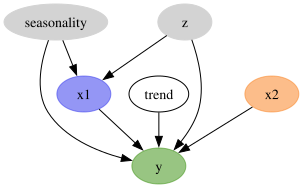

In [4]:
g = gr.Digraph()
g.node(name="seasonality", label="seasonality", color="lightgray", style="filled")
g.node(name="trend", label="trend")
g.node(name="z", label="z", color="lightgray", style="filled")
g.node(name="x1", label="x1", color="#2a2eec80", style="filled")
g.node(name="x2", label="x2", color="#fa7c1780", style="filled")
g.node(name="y", label="y", color="#328c0680", style="filled")
g.edge(tail_name="seasonality", head_name="x1")
g.edge(tail_name="z", head_name="x1")
g.edge(tail_name="x1", head_name="y")
g.edge(tail_name="seasonality", head_name="y")
g.edge(tail_name="trend", head_name="y")
g.edge(tail_name="z", head_name="y")
g.edge(tail_name="x2", head_name="y")
g

The key feature is `z`: a variable that drives both spend on `x1` and sales `y`,
and which we do **not** observe. This is a textbook confounder. Because `z` is
missing from the model, part of its effect on `y` gets attributed to `x1`, and
the model will overstate how effective `x1` is.

Channel `x2` carries no confounding bias of its own: nothing in the graph drives
both `x2` and `y`. That does not mean the model recovers it cleanly. When `x1` is
overstated, the rest of the decomposition has to give up sales it was explaining,
and `x2` is part of that remainder, so its estimate can be dragged off target
indirectly. The contrast between the two channels is therefore direct bias versus
inherited bias, not bias versus a clean control.

Since we simulated the data, we know the true ROAS of each channel.

In [5]:
true_roas_x1 = (raw_df["y"] - raw_df["y01"]).sum() / raw_df["x1"].sum()
true_roas_x2 = (raw_df["y"] - raw_df["y02"]).sum() / raw_df["x2"].sum()

true_roas = {"x1": true_roas_x1, "x2": true_roas_x2}

print(f"True ROAS for x1: {true_roas_x1:.2f}")
print(f"True ROAS for x2: {true_roas_x2:.2f}")

True ROAS for x1: 93.39
True ROAS for x2: 171.41


```{note}
These ROAS values are in the hundreds because the simulated target is scaled by
an amplitude factor. Do not read them as realistic revenue multiples. What
matters for this notebook is the *ratio* between the two channels and whether we
recover it.
```

Let us look at the series before modelling.

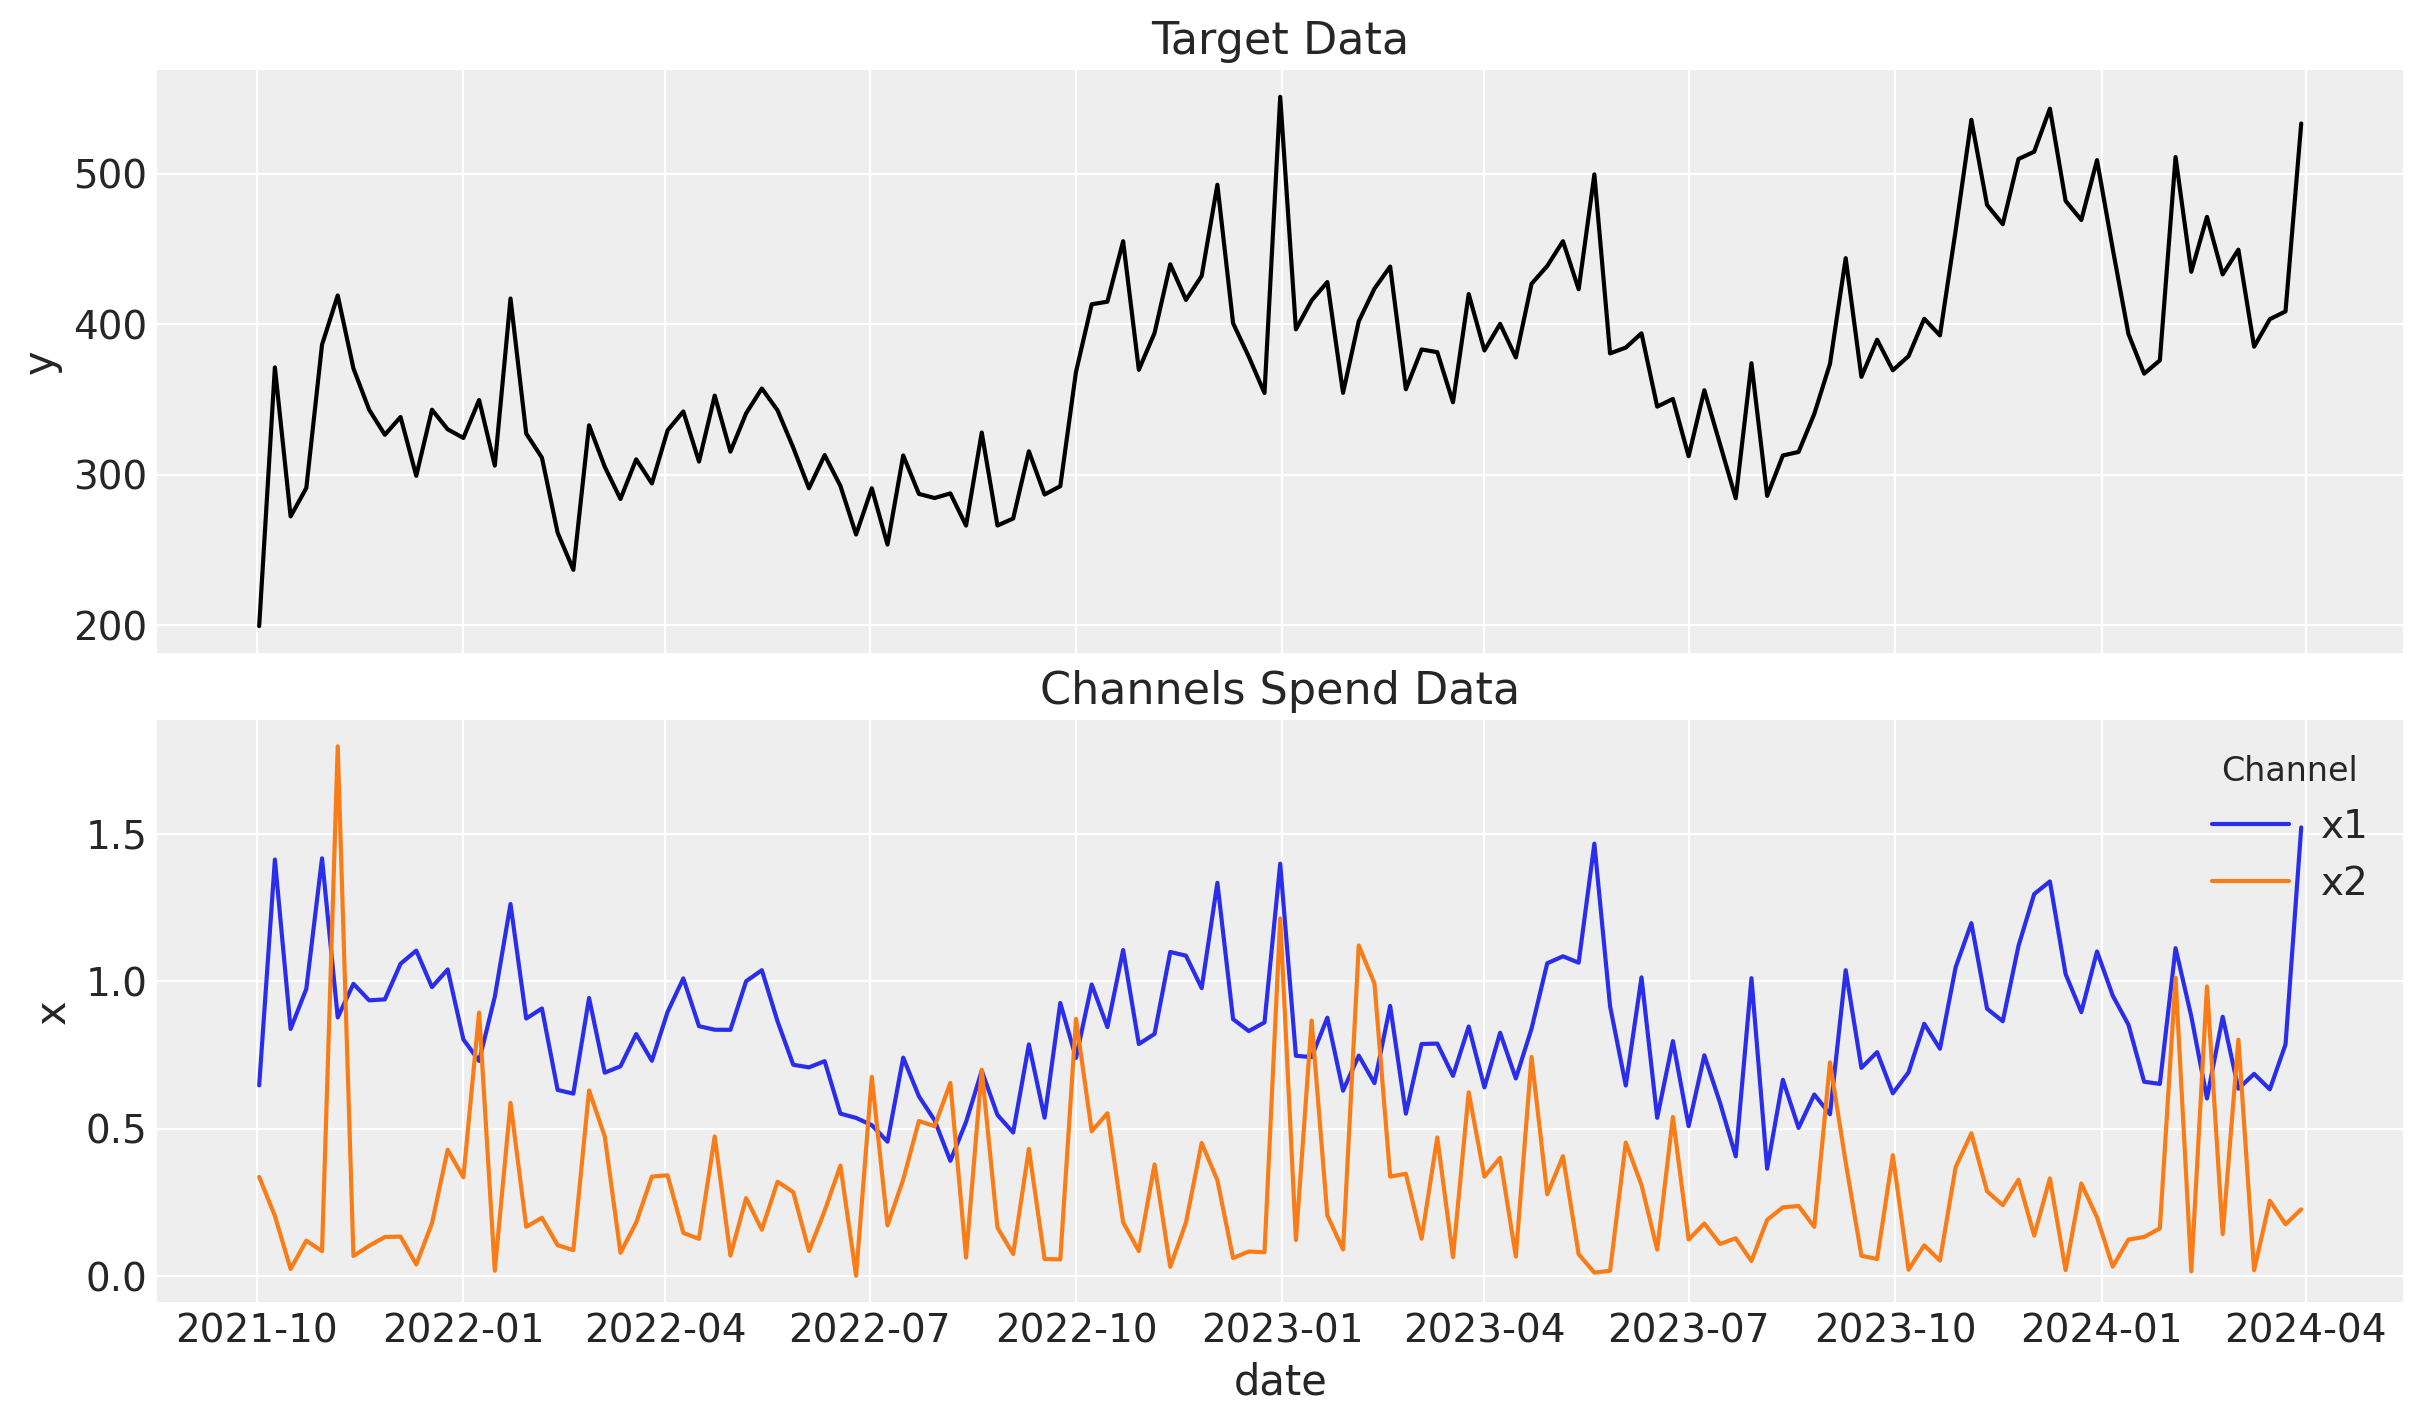

In [6]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    sharey=False,
    layout="constrained",
)

sns.lineplot(x="date", y="y", data=model_df, color="black", ax=ax[0])
ax[0].set_title("Target Data")

model_df.melt(
    id_vars=["date"], value_vars=["x1", "x2"], var_name="channel", value_name="x"
).pipe(
    (sns.lineplot, "data"),
    x="date",
    y="x",
    hue="channel",
    ax=ax[1],
)
ax[1].legend(title="Channel", title_fontsize=12)
ax[1].set_title("Channels Spend Data");

## The Naive Model

We start with a model that sees only `date`, `x1`, `x2` and `y`. No experiment
information at all. This is our baseline and it uses exactly the same
configuration as the baseline model in the {ref}`mmm_roas` notebook, so the two
notebooks are directly comparable.

Without external information, a sensible default is to encode the *cost share*
of each channel into the prior of its coefficient: channels that absorb more of
the budget are given more room to contribute.

In [7]:
cost_share = DataArray(
    model_df[["x1", "x2"]].sum() / model_df[["x1", "x2"]].sum().sum(),
    dims="channel",
)

cost_share

<xarray.DataArray (channel: 2)> Size: 16B
array([0.7366047, 0.2633953])
Coordinates:
  * channel  (channel) object 16B 'x1' 'x2'

In [8]:
model_config = {
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": HSGPKwargs(
        m=100, L=None, eta_lam=1.0, ls_mu=5.0, ls_sigma=10.0, cov_func=None
    ),
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=2, beta=2, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share, dims="channel"),
}

A Gaussian process handles the non-linear trend through a time-varying intercept
(see {ref}`mmm_tv_intercept`). We collect the constructor arguments and the
sampler settings in dictionaries so that every model in this notebook is built
identically and only the calibration differs.

In [9]:
mmm_kwargs = dict(
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
    date_column="date",
    channel_columns=["x1", "x2"],
    target_column="y",
    time_varying_intercept=True,
    time_varying_media=False,
    yearly_seasonality=5,
    model_config=model_config,
)

sampler_config = {
    "tune": 1_000,
    "chains": 4,
    "draws": 1_000,
    "nuts_sampler": "nutpie",
    "target_accept": 0.95,
    "random_seed": rng,
}

y = model_df["y"]
X = model_df.drop(columns=["y"])

One detail matters for everything that follows. Calibration compares model
contribution against spend in **original units**, so the model has to expose the
channel contribution on its original scale. That is what
`add_original_scale_contribution_variable` does, and the calibration method will
raise a clear error if you forget it.

In [10]:
%%time

mmm_naive = MMM(**mmm_kwargs)

vars_of_interest = [
    "channel_contribution",
    "fourier_contribution",
    "intercept_contribution",
    "y",
]

mmm_naive.build_model(X, y)
mmm_naive.add_original_scale_contribution_variable(var=vars_of_interest)
_ = mmm_naive.fit(X, y, **sampler_config)

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Output()

CPU times: user 17.2 s, sys: 461 ms, total: 17.6 s
Wall time: 7.41 s


In [11]:
# Number of diverging samples
mmm_naive.idata["sample_stats"]["diverging"].sum().item()

No divergences, so the geometry is fine. Let us look at what the model believes
about ROAS. The `incrementality` accessor computes contribution over spend for
us.

One bookkeeping note before reading any plots. Three closely related quantities
appear in this notebook: the **plotted** ROAS below comes from
`contribution_over_spend`, a zero-spend counterfactual that includes carryover
effects; the **calibration target** added later constrains the ratio of mean
channel contribution to mean spend over the fitted dates; and the **true** ROAS
was computed above directly from the simulation's ground-truth columns. For an
additive model like this one they agree in principle, but they are three
different computations, so small numerical differences between them are expected
and not a bug.

In [12]:
def get_roas(mmm: MMM) -> DataArray:
    """Posterior ROAS per channel, aggregated over the whole period."""
    return mmm.incrementality.contribution_over_spend(frequency="all_time").rename(
        "roas"
    )


roas_naive = get_roas(mmm_naive)

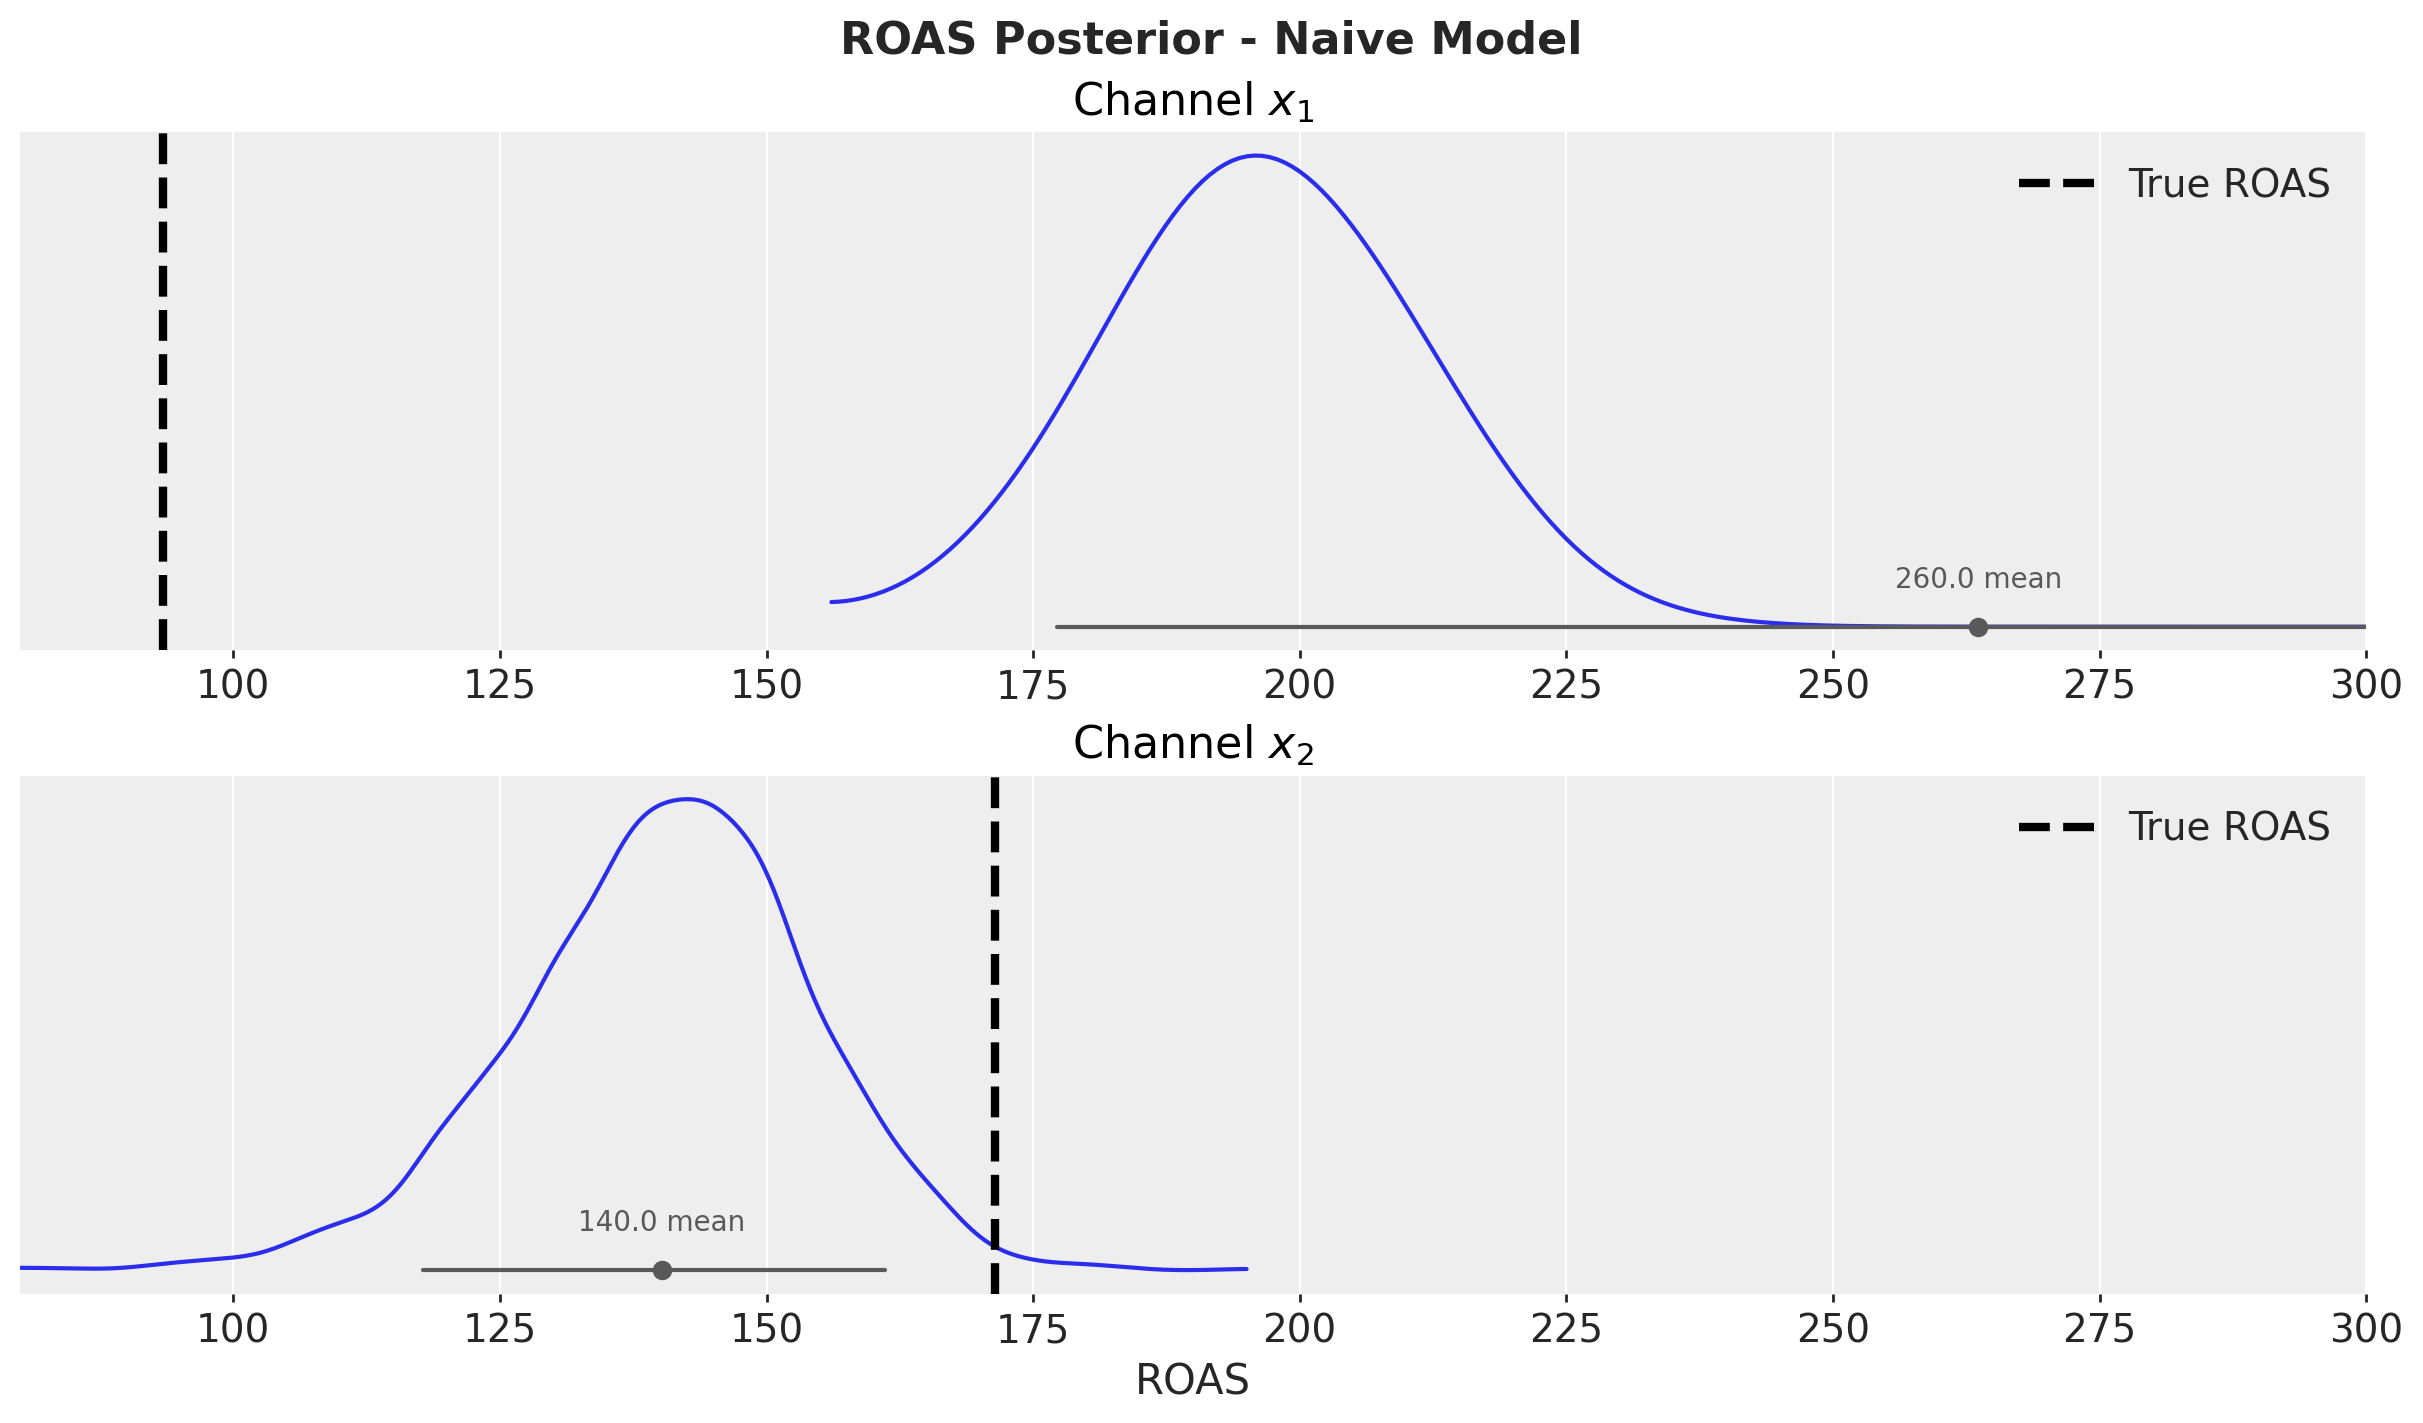

In [13]:
pc = azp.plot_dist(
    roas_naive.to_dataset(name="roas"),
    col_wrap=1,
    figure_kwargs={
        "figsize": (12, 7),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
axes = fig.axes
for ax, channel in zip(axes, ["x1", "x2"], strict=False):
    ax.axvline(
        true_roas[channel],
        color="black",
        linestyle="--",
        linewidth=3,
        label="True ROAS",
    )
    ax.legend(loc="upper right")
    ax.set(title=f"Channel ${channel[0]}_{{{channel[1]}}}$", xlim=(80, 300))
axes[-1].set(xlabel="ROAS")
fig.suptitle("ROAS Posterior - Naive Model", fontsize=16, fontweight="bold");

Neither channel is recovered, and `x1` is the dramatic failure.
The posterior mean sits at about $260$ against a true ROAS of $93$, nearly three times the truth, and the $94\%$ interval, roughly $170$ to $475$, is nowhere near it.
The posterior is also strongly right-skewed, which is why its mean sits well to the right of the density's peak.
This is the confounder at work.

`x2` is the milder case: about $140$ against a true $171$, low by roughly $18\%$, with the truth outside its interval.
Note that `x2` is not confounded, so its error is inherited rather than direct.
When one channel's contribution is overstated, the rest of the model has to give up some of the sales it was explaining, and `x2` is part of that remainder.
This notebook does not isolate that mechanism, so treat it as the likely reading rather than a demonstrated one.

The consequence that matters is not the individual errors, it is the ordering.
The model ranks `x1` above `x2` when the truth is the opposite.
A budget recommendation built on this posterior moves money in the wrong direction.

No amount of extra sales data fixes this.
The bias is structural, not statistical.
We need information from outside the sales series.


## Adding a ROAS Calibration

Suppose the measurement team ran geo lift experiments on both channels and
reported a ROAS point estimate with a standard error for each. That is exactly
the input `add_cost_per_target_calibration` expects.

The calibration table needs one row per experiment, with:

| column | meaning |
|---|---|
| `channel` | which channel the experiment measured, matching `channel_columns` |
| *value column* | the measured ROAS (or CPA); you choose the column name |
| `sigma` | how much deviation you accept, on the same scale as the value |
| *dims columns* | one column per model dimension, for example `geo`, when the model has them |

Our model has no extra dimensions, so `channel`, the value, and `sigma` are all
we need.

In [14]:
roas_calibration_df = pd.DataFrame(
    {
        "channel": ["x1", "x2"],
        "roas": [true_roas_x1, true_roas_x2],
        "sigma": [0.15 * true_roas_x1, 0.15 * true_roas_x2],
    }
)

roas_calibration_df

,channel,roas,sigma
0,x1,93.388131,14.008220
1,x2,171.408804,25.711321


```{admonition} Where these numbers come from in practice
:class: warning

We plug in the true ROAS because this is a simulation and we want to check
recovery. In a real project the value column comes from an experiment readout
and `sigma` comes from that experiment's own uncertainty, not from a guess. A
geo lift analysis in [CausalPy](https://causalpy.readthedocs.io/en/stable/), for
instance, gives you a posterior over the incremental effect; its standard
deviation is a defensible `sigma`.

Never calibrate to a number that came out of another MMM. You would be feeding
the model its own opinion back as evidence.
```

Here `sigma` is $15\%$ of each ROAS value, which is a moderate stance: we take the
experiments seriously but leave the sales likelihood some room to disagree.

Now we build the calibrated model. Note the ordering, which the API enforces:

1. `build_model` &mdash; the calibration needs a model to attach to.
2. `add_original_scale_contribution_variable` &mdash; the calibration needs the
   contribution in original units.
3. `add_cost_per_target_calibration` &mdash; add the observed likelihood.
4. `fit`.

In [15]:
mmm_calibrated = MMM(**mmm_kwargs)

mmm_calibrated.build_model(X, y)
mmm_calibrated.add_original_scale_contribution_variable(var=vars_of_interest)

mmm_calibrated.add_cost_per_target_calibration(
    data=X,
    calibration_data=roas_calibration_df,
    name_prefix="roas_calibration",
    target_column="roas",
    target_per_cost=True,
);

Three arguments deserve comment.

`data` is a spend table with the same layout as `X`. In this dataset the channel
columns already *are* spend, so we pass `X` directly. If your model is fit on
impressions or GRPs rather than money, this is where you supply the matching
monetary spend, and getting it right is what makes the resulting ratio a real
ROAS.

`target_column` tells the method which column holds the calibration values. It
defaults to `"cost_per_target"`; we named ours `"roas"`, so we say so.

`target_per_cost=True` is the direction switch, and it is the important one:

- `target_per_cost=False` (the default) calibrates
  $\overline{\text{spend}} \,/\, \overline{\text{contribution}}$, which is
  **cost per target**: CPA, CPI, cost per conversion.
- `target_per_cost=True` calibrates
  $\overline{\text{contribution}} \,/\, \overline{\text{spend}}$, which is
  **ROAS** when contribution is revenue.

The two are reciprocals, so in principle either could express the same
constraint. In practice they are not interchangeable, because `sigma` is applied
on whichever scale you pick. A symmetric Normal error on ROAS is not a symmetric
error on CPA. Calibrate on the scale your experiment actually reported.

```{admonition} A note on the likelihood family
:class: caution

The calibration term currently uses a `Normal` likelihood. ROAS and CPA are
strictly positive, so a Normal is technically misspecified: it places some mass
below zero. With a `sigma` that is small relative to the value, as above, this is
harmless. It matters when the calibration target is close to zero relative to its
uncertainty. Making the family configurable is tracked in
[pymc-marketing#2737](https://github.com/pymc-labs/pymc-marketing/issues/2737).
```

Let us confirm what actually got added to the model.

In [16]:
observed_rvs = [rv.name for rv in mmm_calibrated.model.observed_RVs]

print(
    f"Naive model observed variables:      {[rv.name for rv in mmm_naive.model.observed_RVs]}"
)
print(f"Calibrated model observed variables: {observed_rvs}")

Naive model observed variables:      ['y']
Calibrated model observed variables: ['y', 'roas_calibration']


The naive model observes only `y`. The calibrated model observes `y` **and**
`roas_calibration`. That second node is the whole mechanism: two likelihood terms
instead of one, and the posterior has to satisfy both.

Now we fit.

In [17]:
%%time

_ = mmm_calibrated.fit(X, y, **sampler_config)

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Output()

CPU times: user 16.2 s, sys: 328 ms, total: 16.5 s
Wall time: 6.25 s


In [18]:
# Number of diverging samples
mmm_calibrated.idata["sample_stats"]["diverging"].sum().item()

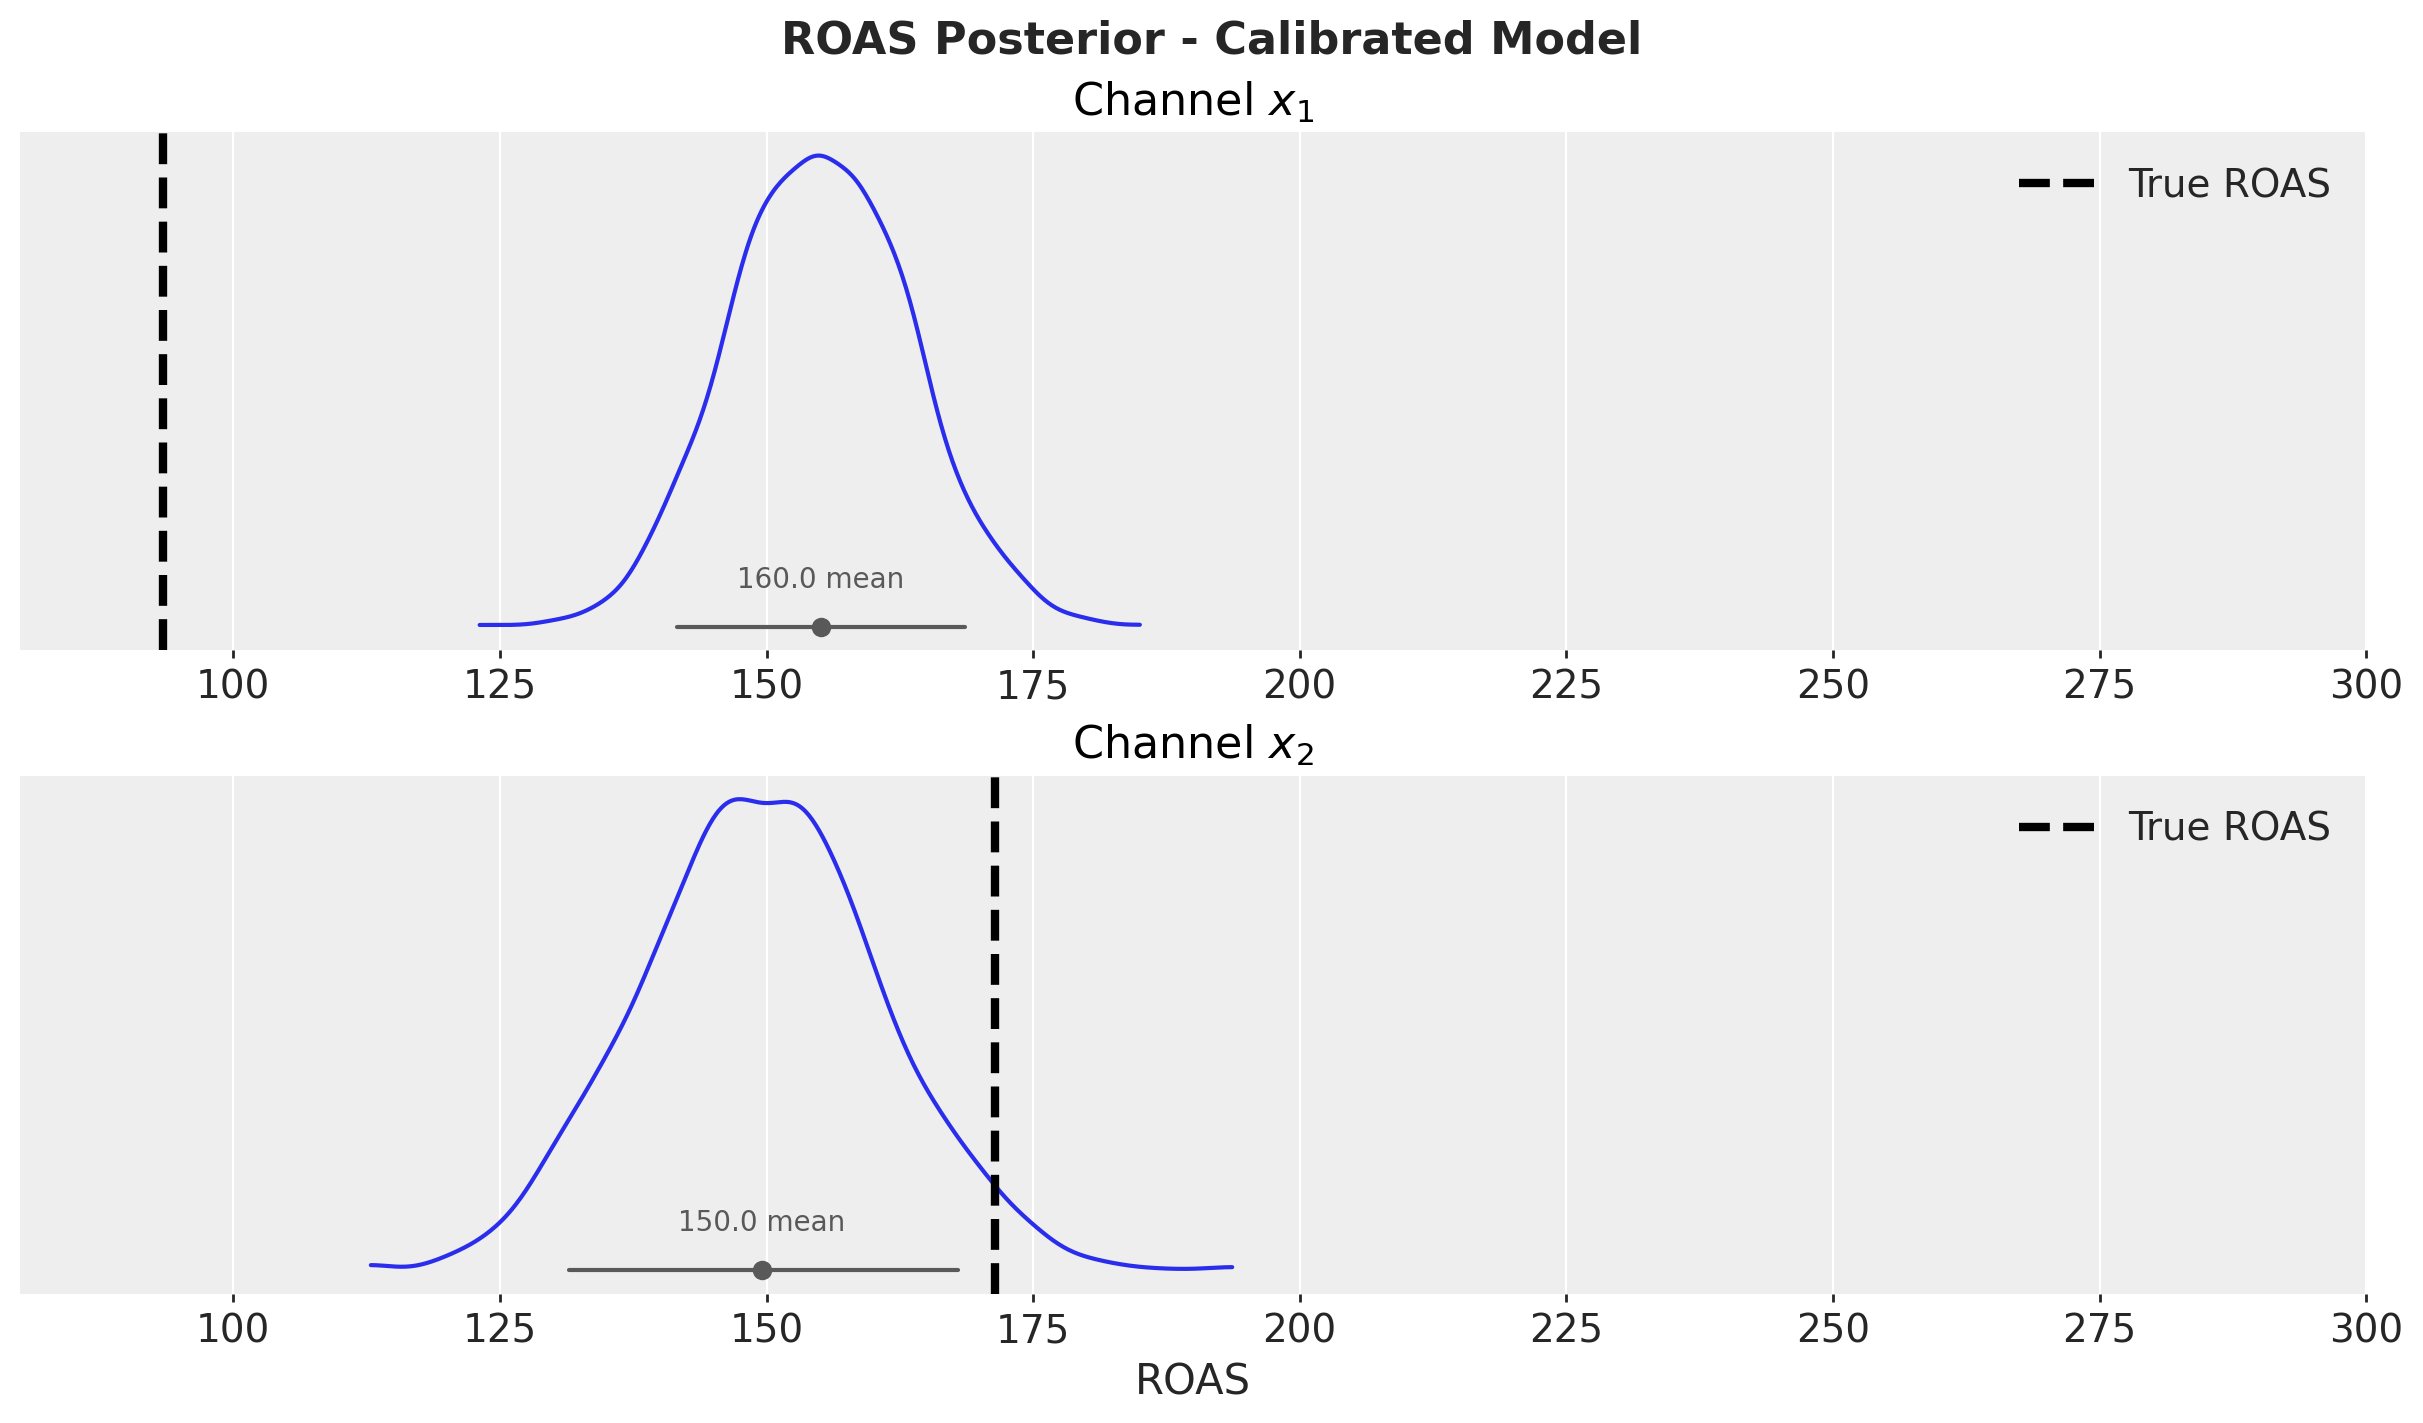

In [19]:
roas_calibrated = get_roas(mmm_calibrated)

pc = azp.plot_dist(
    roas_calibrated.to_dataset(name="roas"),
    col_wrap=1,
    figure_kwargs={
        "figsize": (12, 7),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
axes = fig.axes
for ax, channel in zip(axes, ["x1", "x2"], strict=False):
    ax.axvline(
        true_roas[channel],
        color="black",
        linestyle="--",
        linewidth=3,
        label="True ROAS",
    )
    ax.legend(loc="upper right")
    ax.set(title=f"Channel ${channel[0]}_{{{channel[1]}}}$", xlim=(80, 300))
axes[-1].set(xlabel="ROAS")
fig.suptitle("ROAS Posterior - Calibrated Model", fontsize=16, fontweight="bold");

This calibration helps the model estimates, but just partially mitigates the confounding effect.
The `x1` posterior mean moves from about $260$ down to $155$ against a true $93$, so roughly two thirds of the error is gone, and `x2` moves from $140$ up to $150$ against a true $171$.
The truth is still outside both $94\%$ intervals, and the ranking is still inverted: about $155$ for `x1` against $150$ for `x2`.

That is a weaker result than "calibration fixes it", and the reason is `sigma`.
We asked for $15\%$ relative uncertainty, which leaves the sales likelihood a lot of room to disagree, and it uses it.
The next section refits with a tighter and a looser calibration so you can see how much of the answer is controlled by that one number.


## How `sigma` Controls the Pull

`sigma` is the only real dial and it is worth seeing it move. We refit the model
with a tight calibration ($5\%$ relative uncertainty) and a loose one ($60\%$), keeping
everything else fixed.

In [20]:
%%time

sigma_scenarios = {"tight (5%)": 0.05, "loose (60%)": 0.60}
mmm_sigma = {}

for label, rel_sigma in sigma_scenarios.items():
    calibration_df = roas_calibration_df.assign(
        sigma=lambda df, r=rel_sigma: r * df["roas"]
    )

    mmm_s = MMM(**mmm_kwargs)
    mmm_s.build_model(X, y)
    mmm_s.add_original_scale_contribution_variable(var=vars_of_interest)
    mmm_s.add_cost_per_target_calibration(
        data=X,
        calibration_data=calibration_df,
        name_prefix="roas_calibration",
        target_column="roas",
        target_per_cost=True,
    )
    _ = mmm_s.fit(X, y, **sampler_config)
    mmm_sigma[label] = mmm_s

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Output()

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline]


Output()

Output()

CPU times: user 30.9 s, sys: 605 ms, total: 31.5 s
Wall time: 12 s


## Comparing the Models

A forest plot is the natural way to compare posteriors across models: it puts
every interval on one axis so the shrinkage is immediately visible.

In [21]:
roas_by_model = {
    "naive": roas_naive,
    "calibrated, tight (5%)": get_roas(mmm_sigma["tight (5%)"]),
    "calibrated, moderate (15%)": roas_calibrated,
    "calibrated, loose (60%)": get_roas(mmm_sigma["loose (60%)"]),
}

combined = xr.concat(
    [roas.to_dataset() for roas in roas_by_model.values()], dim="model"
).assign_coords(model=list(roas_by_model))

dt = xr.DataTree.from_dict({"/posterior": xr.DataTree(combined)})

combined

<xarray.Dataset> Size: 264kB
Dimensions:  (model: 4, chain: 4, draw: 1000, channel: 2)
Coordinates:
  * model    (model) <U26 416B 'naive' ... 'calibrated, loose (60%)'
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * channel  (channel) <U2 16B 'x1' 'x2'
Data variables:
    roas     (model, chain, draw, channel) float64 256kB 220.6 127.7 ... 137.8

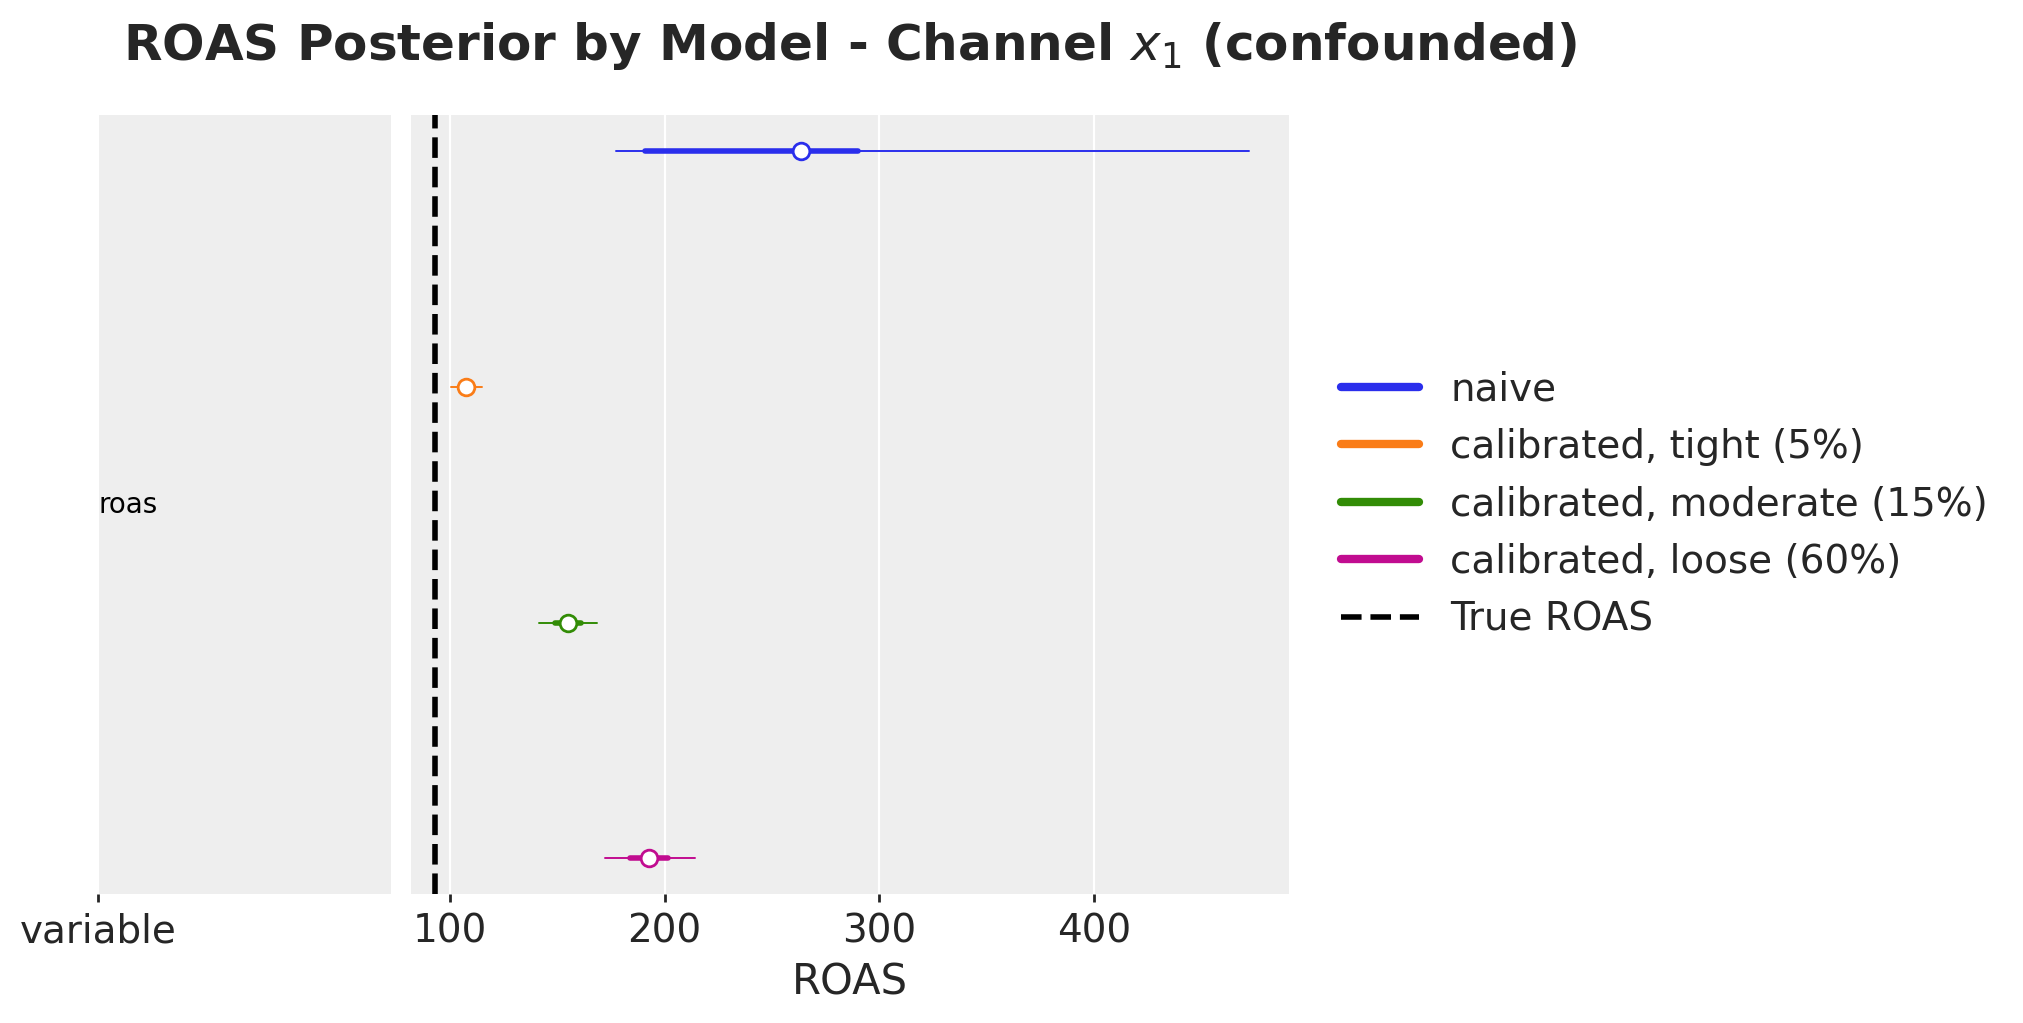

In [22]:
def plot_model_forest(datatree: xr.DataTree, channel: str, true_value: float):
    """Forest plot of ROAS posteriors across models for a single channel."""
    pc = azp.plot_forest(
        datatree.sel(channel=channel),
        combined=True,
        figure_kwargs={"figsize": (10, 5)},
    )
    ax = pc.viz["plot"].sel(column="forest").item()
    ax.axvline(true_value, color="black", linestyle="--", linewidth=2)
    ax.set(xlabel="ROAS")

    color_map = pc.aes["color"]["mapping"]
    handles = [
        Line2D([0], [0], color=str(color_map.sel(model=m).values), linewidth=3)
        for m in datatree["posterior"].coords["model"].values
    ]
    handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=2))
    labels = [*list(datatree["posterior"].coords["model"].values), "True ROAS"]
    ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5))
    return pc, ax


pc, ax = plot_model_forest(dt, channel="x1", true_value=true_roas_x1)
ax.set_title(
    "ROAS Posterior by Model - Channel $x_{1}$ (confounded)",
    fontsize=18,
    fontweight="bold",
    y=1.05,
);

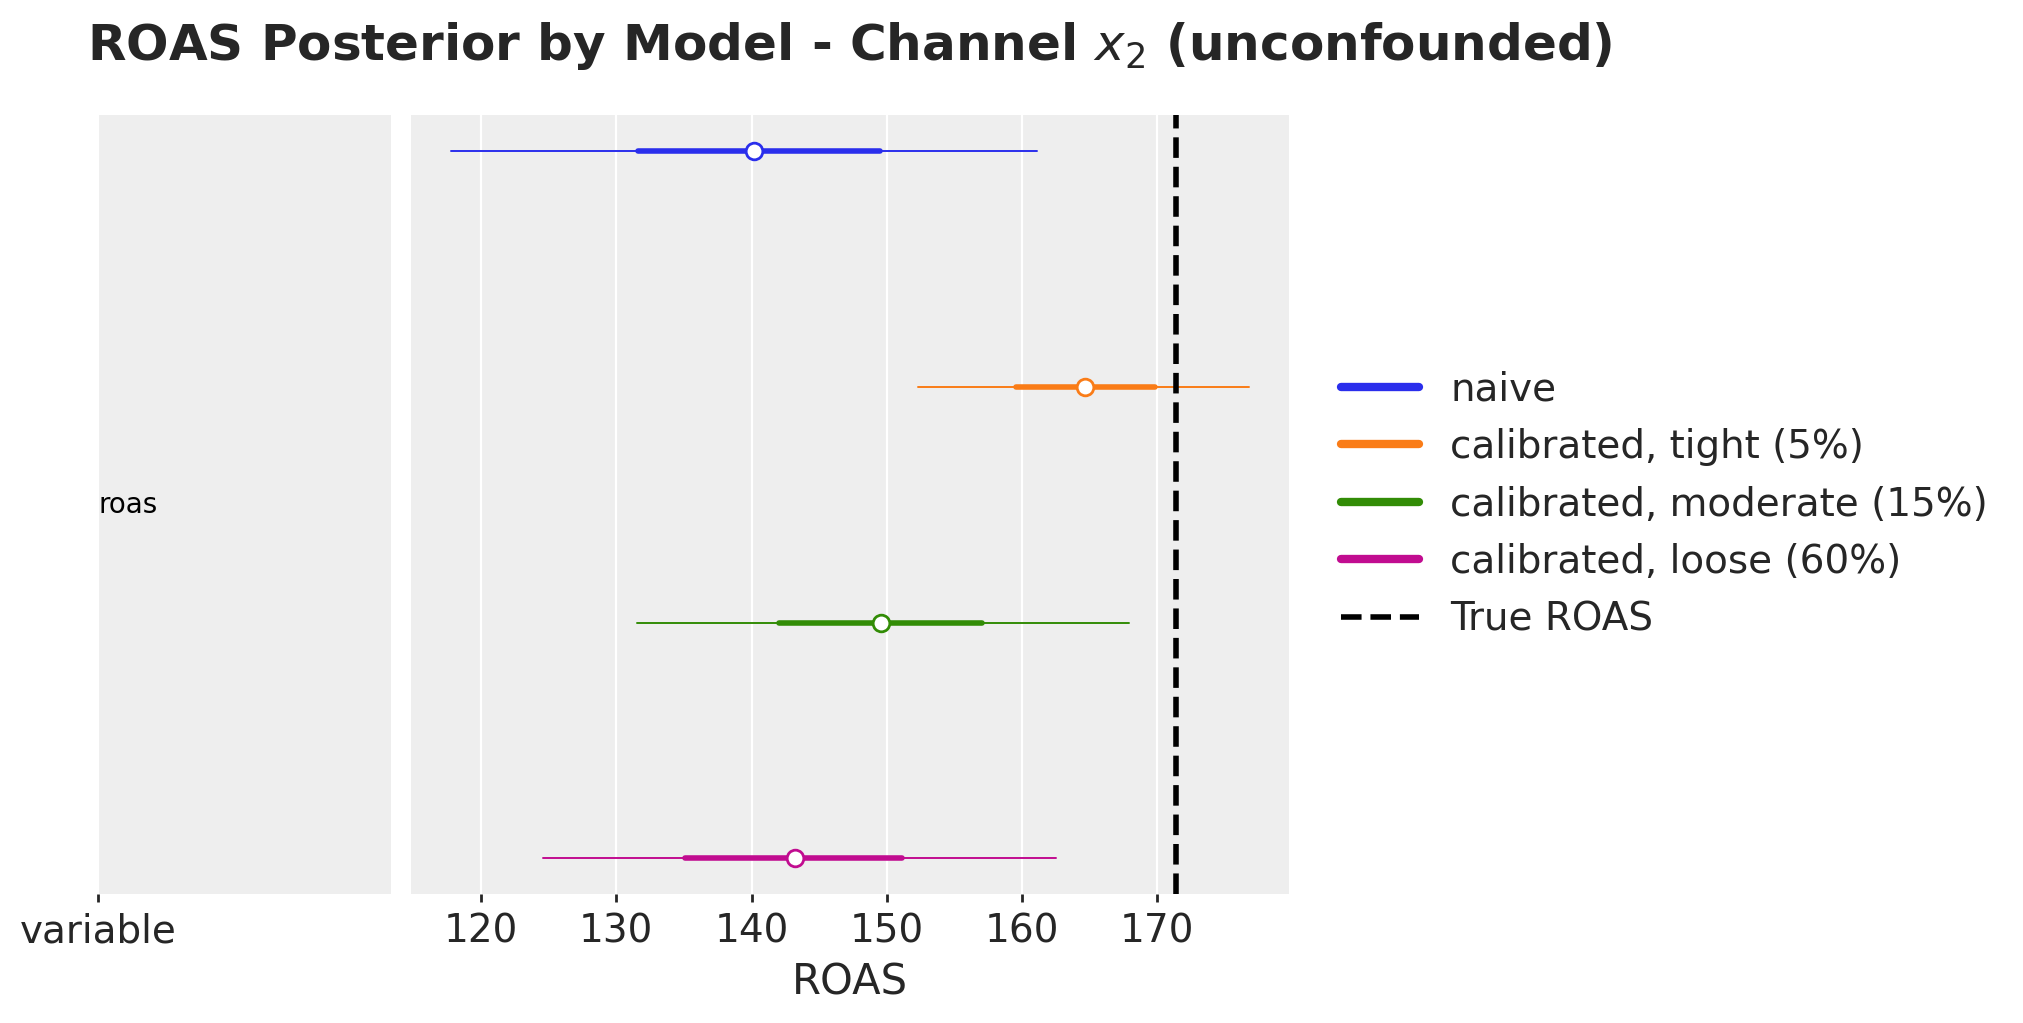

In [23]:
pc, ax = plot_model_forest(dt, channel="x2", true_value=true_roas_x2)
ax.set_title(
    "ROAS Posterior by Model - Channel $x_{2}$ (unconfounded)",
    fontsize=18,
    fontweight="bold",
    y=1.05,
);

In [24]:
# Posterior probability that the ranking is correct (true ROAS: x2 > x1),
# computed per model from the joint posterior rather than from point estimates.
prob_correct_ranking = (
    (combined["roas"].sel(channel="x2") > combined["roas"].sel(channel="x1"))
    .mean(dim=("chain", "draw"))
    .rename("P(ROAS_x2 > ROAS_x1)")
    .to_dataframe()
)

prob_correct_ranking

,P(ROAS_x2 > ROAS_x1)
model,
naive,0.00100
"calibrated, tight (5%)",1.00000
"calibrated, moderate (15%)",0.34500
"calibrated, loose (60%)",0.00225


The `x1` panel, read against the dashed line at the true ROAS of $93$, tells a more nuanced story than "calibration works".

Two things work as advertised:

- Every calibrated model moves toward the truth, and the ordering follows `sigma` exactly.
  The tight ($5\%$) calibration lands nearest with a posterior mean near $108$, the moderate ($15\%$) one at about $155$, and the loose ($60\%$) one at about $192$, against the naive model's $260$.
- The loose calibration stays closest to the naive fit: it settles where the bulk of the naive posterior sits, merely trimming the naive model's long upper tail.
  That is the honest behaviour when you have told the model not to trust the experiment.

One thing does not.
None of the `x1` intervals contains the true value, the tight one included: its $94\%$ interval runs from about $100$ to $116$, which excludes $93$ at the low end.
The calibration enters as a single observation competing against every date in the sales series, so even at $5\%$ relative uncertainty the plotted posterior mean of about $108$ settles roughly three `sigma` (here $5\%$ of $93$, about $4.7$) above the calibration target of $93$ rather than on it.
Tightening `sigma` buys a large reduction in bias here, not exact recovery.
If you need the experiment to constrain the model more firmly than that, a whole-period ratio is the wrong instrument; see the note on matching the time window below, and {ref}`mmm_lift_test` for a constraint anchored to the dates the experiment ran.

The `x2` panel shows the inherited bias described earlier.
The naive model was not already right about `x2`: it sits near $140$ against a true $171$, low by about $18\%$, with the truth outside its interval.
Calibration helps here too, and the tight variant is the only model in either panel whose $94\%$ interval covers its true value.

The summary that matters is the ranking, because that is what moves budget.
The truth is `x2` above `x1`, and the table above gives the posterior probability of that ordering under each model, which is the honest way to read a ranking off two overlapping posteriors; the difference between the posterior means is small relative to their spread, so the means alone would overstate the precision.
The naive model and the loose calibration put that probability at about $0.1\%$ and $0.2\%$ respectively, i.e. they bet confidently on the wrong order.
The moderate calibration moves it to about $35\%$, closer to a coin flip but still favouring the wrong order.
Only the tight calibration commits to the correct order, at essentially $100\%$.
So the useful conclusion from this dataset is not that calibration recovers ROAS, it is that a calibration you genuinely trust recovers the decision.

We can look at the same thing as densities rather than intervals.


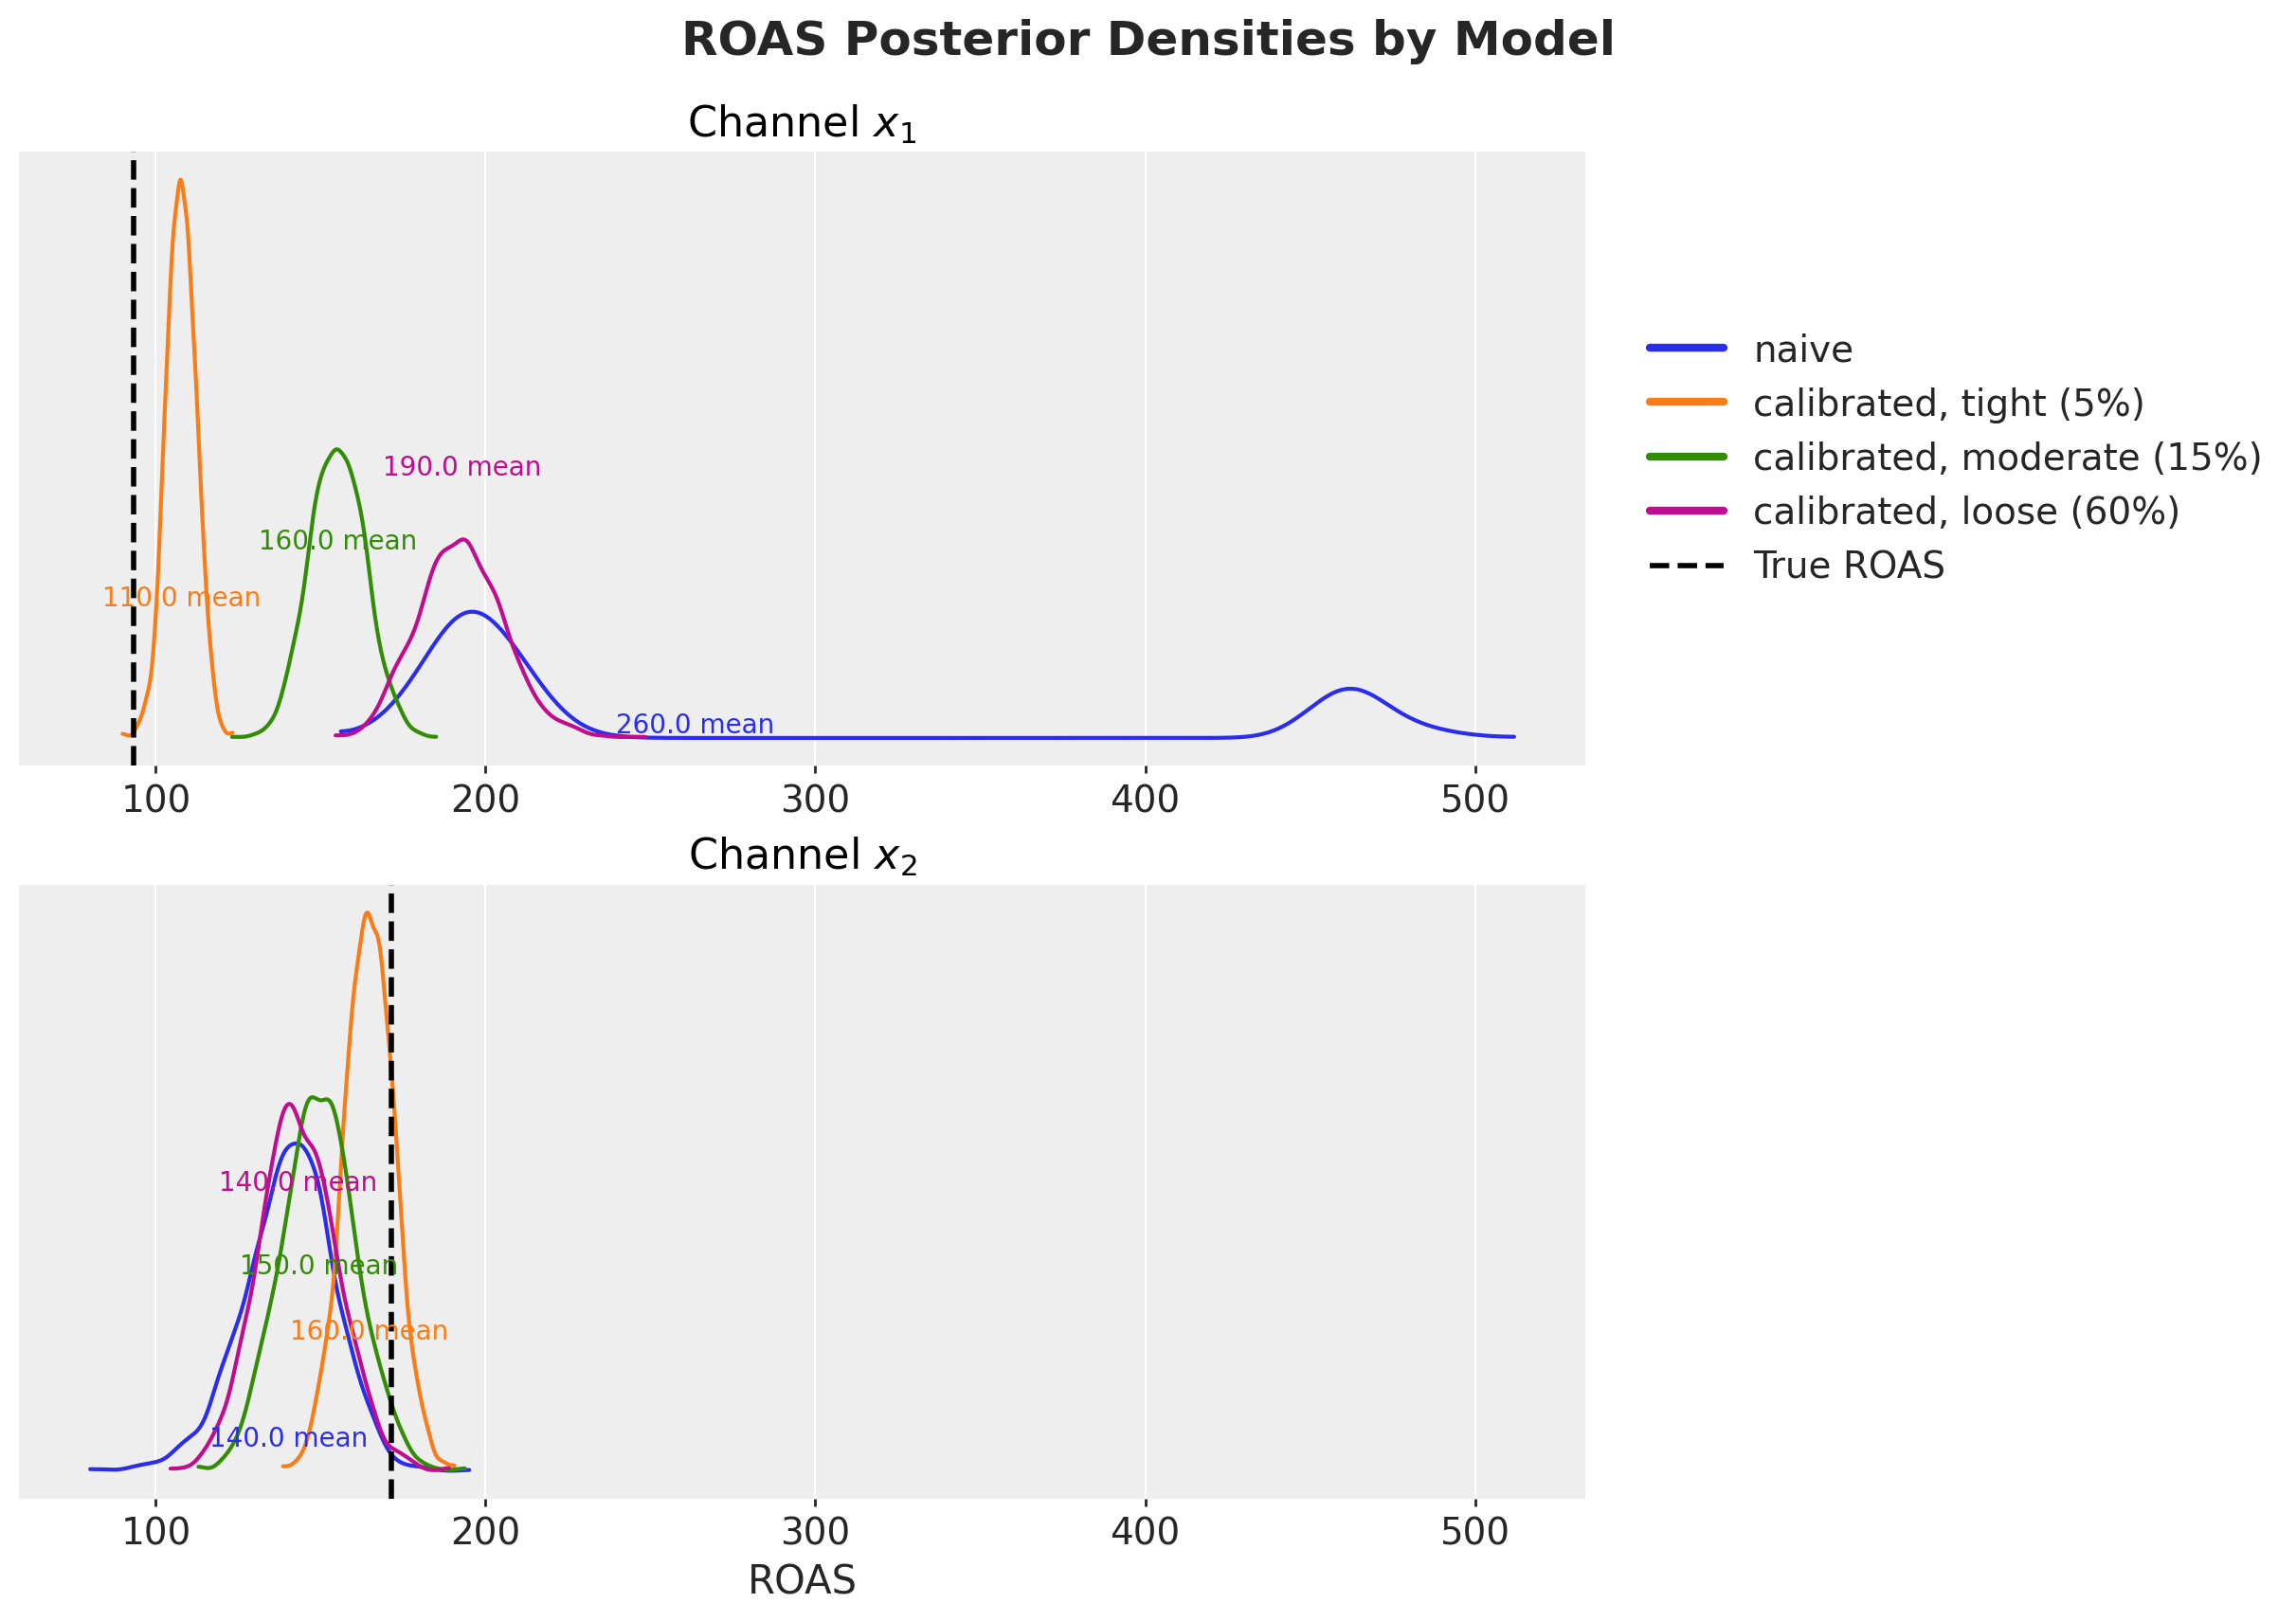

In [25]:
pc = azp.plot_dist(
    dt,
    col_wrap=1,
    visuals={"credible_interval": False, "point_estimate": False},
    figure_kwargs={
        "figsize": (12, 8),
        "sharex": True,
        "sharey": False,
        "layout": "constrained",
    },
)
fig = pc.viz["/"]["figure"].values.item()
axes = fig.axes
for ax, channel in zip(axes, ["x1", "x2"], strict=False):
    ax.axvline(true_roas[channel], color="black", linestyle="--", linewidth=2)
    ax.set(title=f"Channel ${channel[0]}_{{{channel[1]}}}$")
axes[-1].set(xlabel="ROAS")
color_map = pc.aes["color"]["mapping"]
handles = [
    Line2D([0], [0], color=str(color_map.sel(model=m).values), linewidth=3)
    for m in dt["posterior"].coords["model"].values
]
handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=2))
labels = [*list(dt["posterior"].coords["model"].values), "True ROAS"]
axes[0].legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.suptitle(
    "ROAS Posterior Densities by Model", fontsize=18, fontweight="bold", y=1.05
);

The tight calibration produces a visibly narrower density for `x1`, the loose one
a broad density shifted toward the naive answer, and the moderate one sits
between them. Nothing is being clipped or truncated; the sampler is simply
spending its time where both likelihood terms are satisfied.

## What Calibration Costs You

Calibration is not free. Forcing `x1` down means the rest of the model has to
absorb the sales that `x1` was previously explaining, usually through the
intercept and the trend. It is worth checking that the fit to the target has not
degraded in some pathological way.

Sampling: [y]


Output()

Sampling: [roas_calibration, y]


Output()

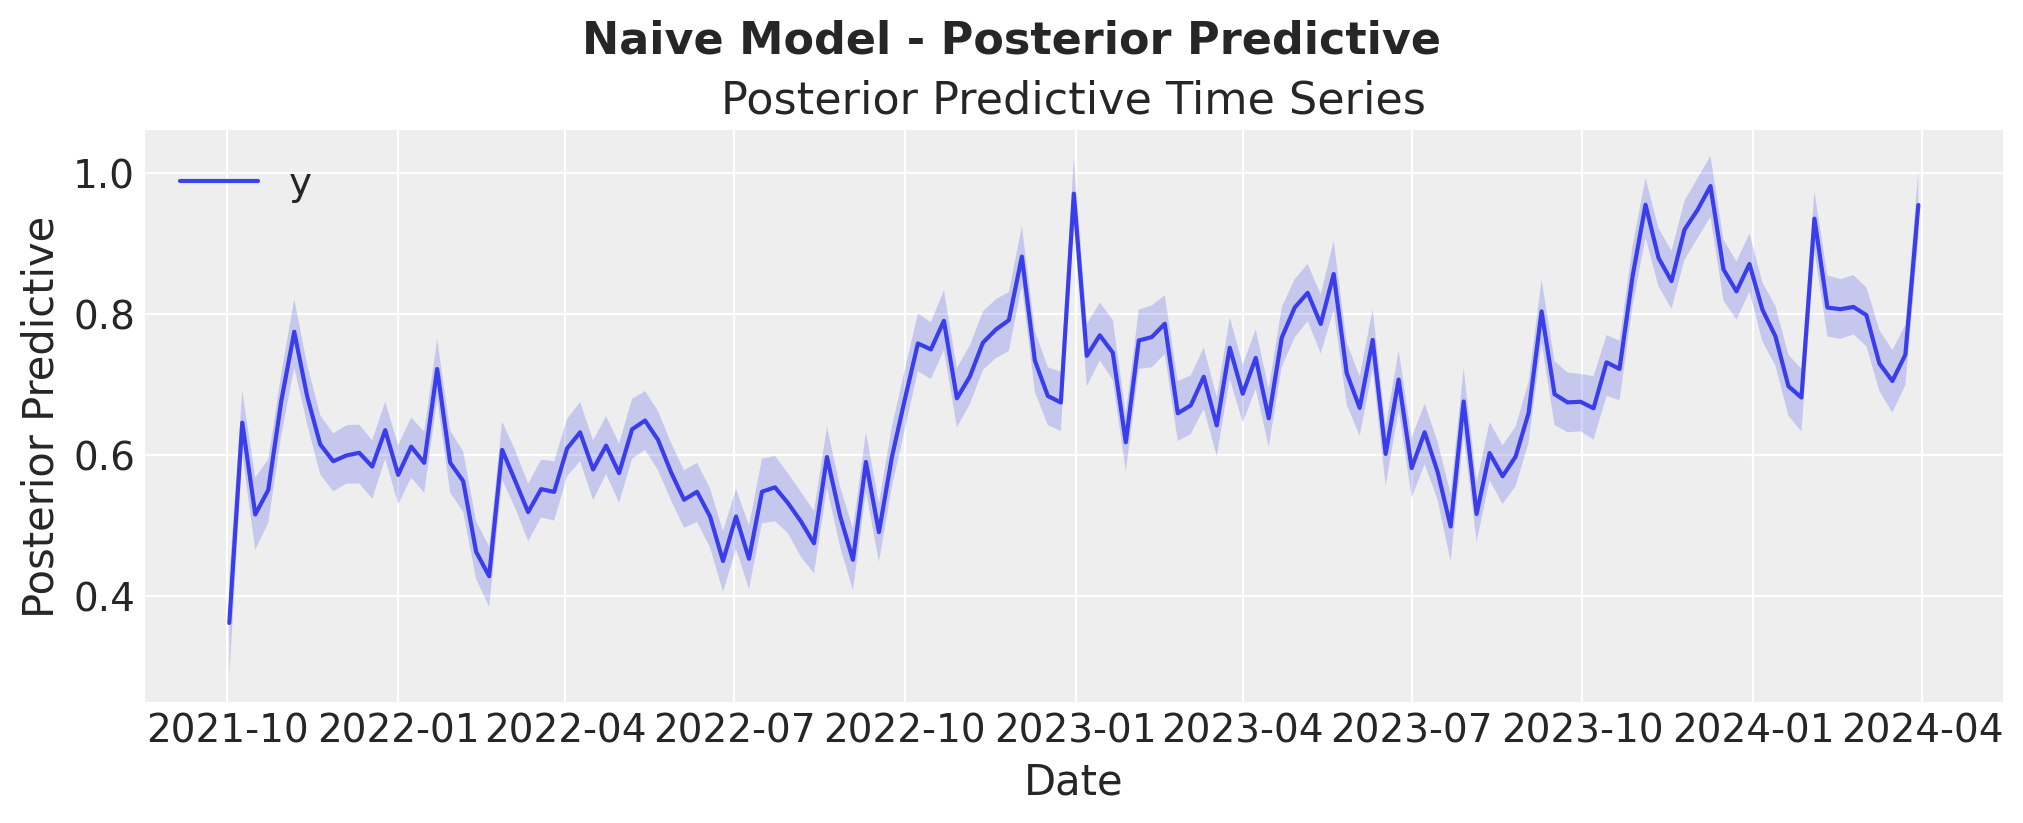

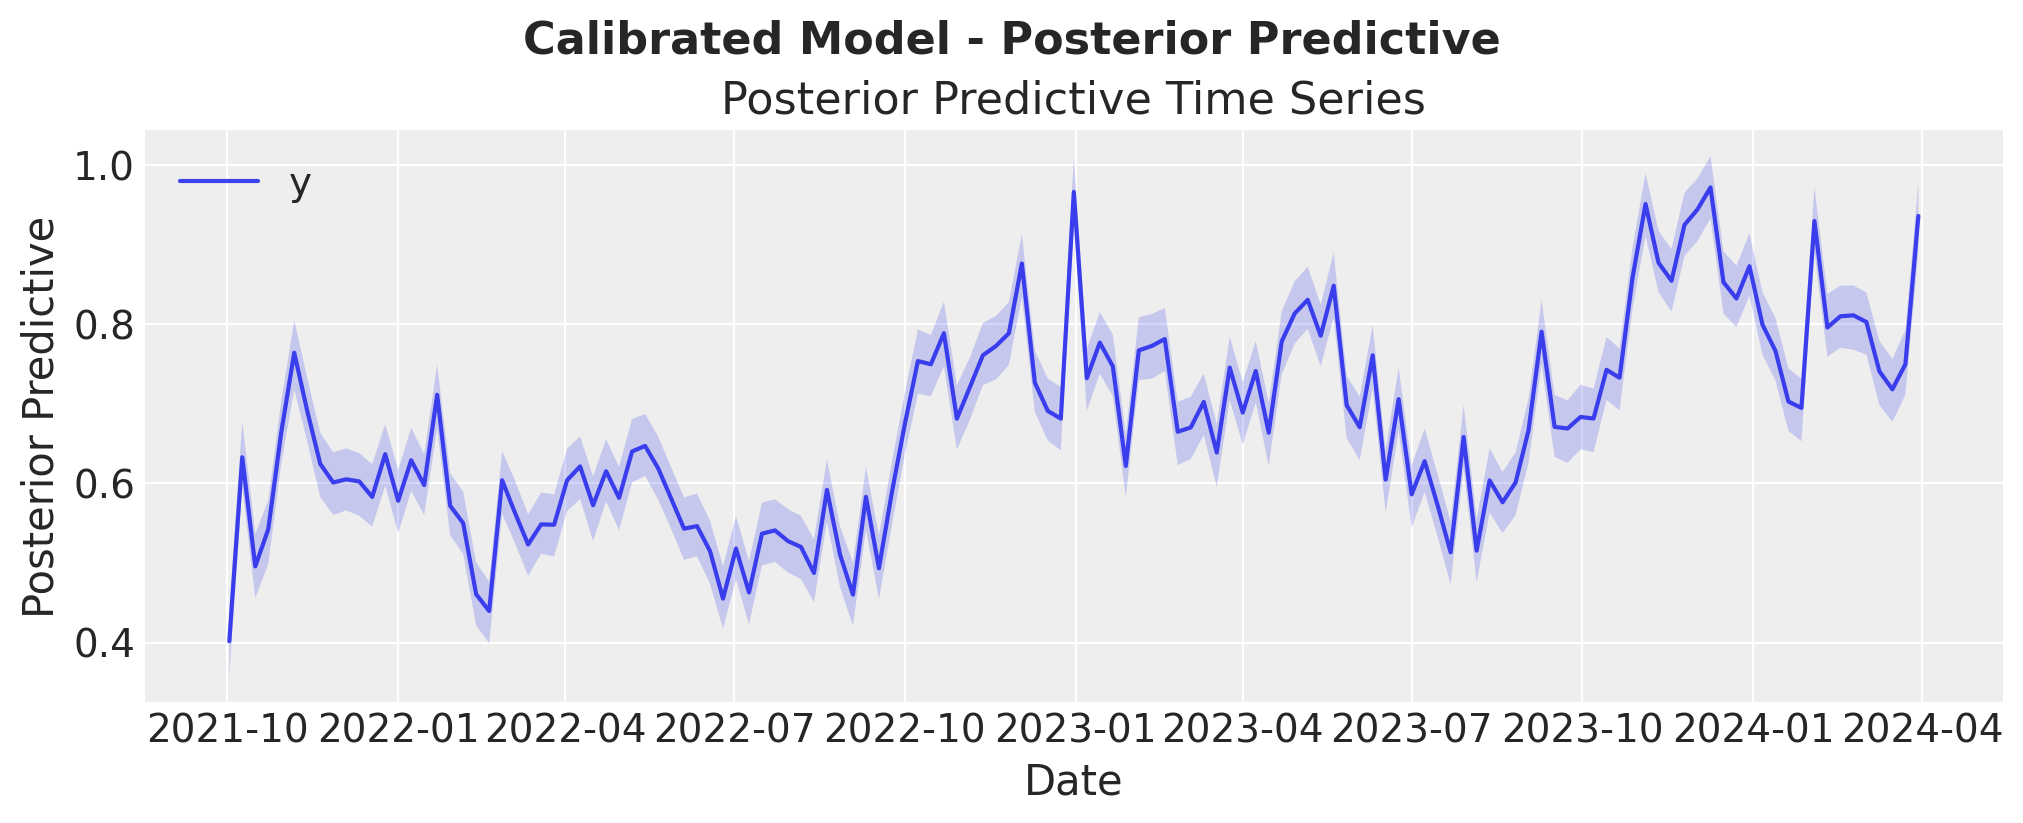

In [26]:
for name, mmm_ in [("Naive", mmm_naive), ("Calibrated", mmm_calibrated)]:
    _ = mmm_.sample_posterior_predictive(
        X, extend_idata=True, combined=True, random_seed=rng
    )
    fig, _ = mmm_.plot.posterior_predictive()
    fig.suptitle(f"{name} Model - Posterior Predictive", fontsize=16, fontweight="bold")

Both models track the target closely. Calibration changed *which* component gets
credit for the sales, not whether the sales are explained.

This is the central lesson, and it is the reason predictive accuracy is a poor
way to choose between MMMs. Two models can fit the observed series equally well
and still give opposite budget advice. Only causal information, from experiments,
separates them. The {ref}`mmm_roas` notebook makes the same point quantitatively
with cross-validated CRPS, where the *uncalibrated* model actually scores better
out of sample while being the more wrong of the two.

## Calibrating on CPA Instead

Many teams do not report ROAS. If your target variable is conversions rather than
revenue, the natural quantity is cost per acquisition, and that is what the
method does by default.

The only changes are the direction flag and the column name.

In [27]:
cpa_calibration_df = pd.DataFrame(
    {
        "channel": ["x1", "x2"],
        "cost_per_target": [1 / true_roas_x1, 1 / true_roas_x2],
        # 15% *relative* uncertainty stated directly on the CPA scale, i.e.
        # 0.15 * (1 / true_roas). This is a fresh sigma choice on the CPA scale,
        # not a reciprocal-converted standard error (see the warning below).
        "sigma": [0.15 / true_roas_x1, 0.15 / true_roas_x2],
    }
)

mmm_cpa = MMM(**mmm_kwargs)
mmm_cpa.build_model(X, y)
mmm_cpa.add_original_scale_contribution_variable(var=vars_of_interest)

# target_per_cost defaults to False, and target_column defaults to
# "cost_per_target", so the CPA direction needs no extra arguments.
mmm_cpa.add_cost_per_target_calibration(
    data=X,
    calibration_data=cpa_calibration_df,
    name_prefix="cpa_calibration",
)

cpa_calibration_df

,channel,cost_per_target,sigma
0,x1,0.010708,0.001606
1,x2,0.005834,0.000875


```{admonition} Do not treat CPA and ROAS as interchangeable
:class: warning

The point estimates are reciprocals, but the *uncertainty* is not. A Normal with
`sigma` on the ROAS scale implies an asymmetric, non-Normal uncertainty on the
CPA scale, and vice versa. Pick the scale your experiment reported its standard
error on, and calibrate there. Converting a standard error by taking a reciprocal
is wrong.
```

We do not refit here; the mechanism is identical to the ROAS case.

## In-Sample Fit Does Not Rank the Models

The plots above were read by eye. The same point can be made with a proper score,
and it is worth doing because the result is counter-intuitive.

The Continuous Ranked Probability Score (CRPS) generalises the mean absolute
error to probabilistic predictions. Instead of comparing a point forecast to the
observation, it compares the whole predictive distribution to it, so a model is
rewarded both for being close and for being honest about its uncertainty. Lower
is better. For the intuition, see the blog post
["Intuition behind CRPS"](https://juanitorduz.github.io/crps/).

We compute it in sample, on the very dates the models were fit to, for all four
models.

In [28]:
def in_sample_crps(mmm_: MMM) -> float:
    """In-sample CRPS of the posterior predictive against the observed target."""
    # crps expects the sample dimension first.
    y_pred = (
        mmm_.idata.posterior["y_original_scale"]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "date")
        .to_numpy()
    )
    y = mmm_.y
    return crps(y, y_pred)


models_by_name = {
    "naive": mmm_naive,
    "calibrated, tight (5%)": mmm_sigma["tight (5%)"],
    "calibrated, moderate (15%)": mmm_calibrated,
    "calibrated, loose (60%)": mmm_sigma["loose (60%)"],
}

crps_by_model = {name: in_sample_crps(m) for name, m in models_by_name.items()}

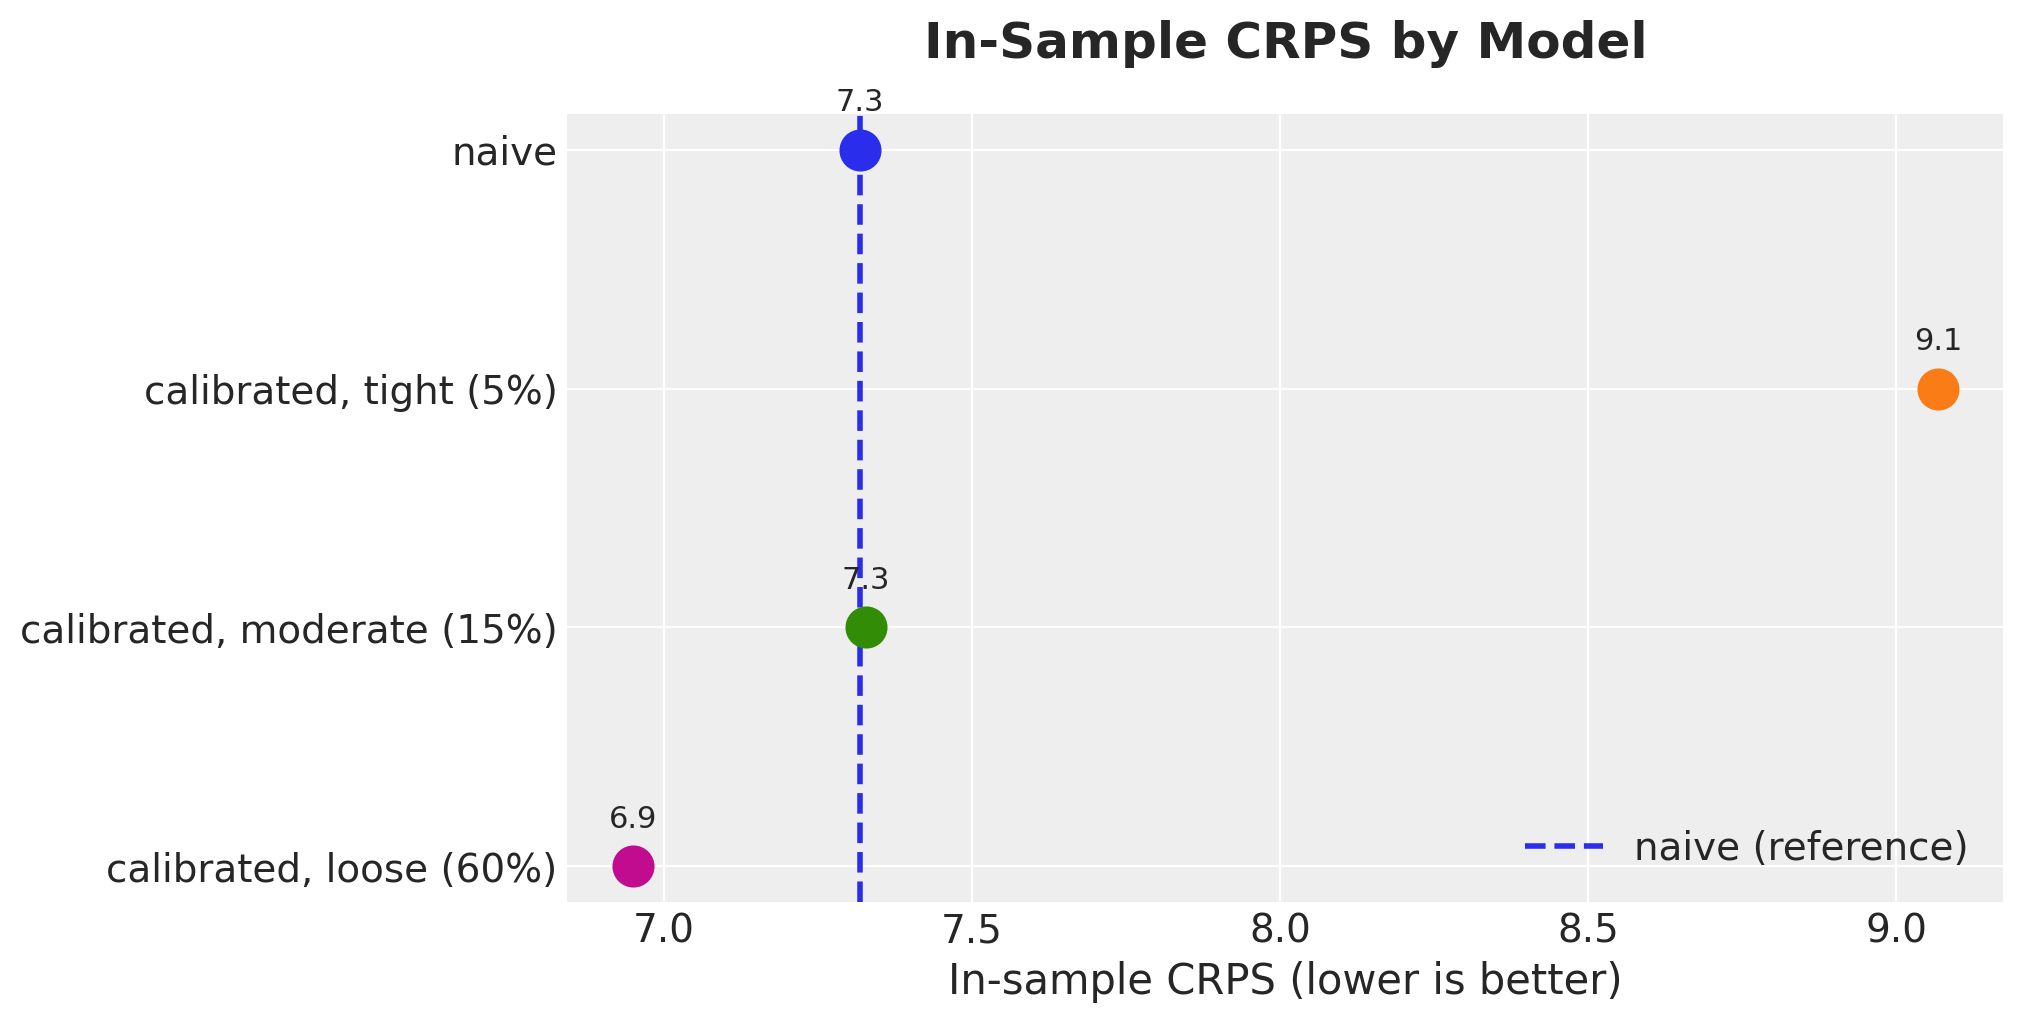

In [29]:
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")

names = list(crps_by_model)
values = [crps_by_model[name] for name in names]

ax.axvline(
    values[0],
    color="C0",
    linestyle="--",
    linewidth=2,
    label="naive (reference)",
)
for i, value in enumerate(values):
    ax.scatter(value, i, s=200, color=f"C{i}", zorder=3)
    ax.annotate(
        f"{value:,.1f}",
        xy=(value, i),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=11,
    )

ax.set_yticks(range(len(names)), names)
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.set(xlabel="In-sample CRPS (lower is better)", ylabel=None)
ax.set_title(
    "In-Sample CRPS by Model",
    fontsize=18,
    fontweight="bold",
    y=1.05,
);

The scores land in almost the opposite order to the causal accuracy:

- calibrated, loose ($60\%$): $6.9$
- naive: $7.3$
- calibrated, moderate ($15\%$): $7.3$
- calibrated, tight ($5\%$): $9.1$

The best score belongs to the loose calibration, the model that stays closest to the naive fit and shares its inverted channel ranking, and the naive model is essentially tied with the moderate calibration just behind it.
The tight calibration, the only model that recovers the correct ranking, comes last, about $30\%$ worse than the best score.

This is not a bug, and it is not a sign that calibration damaged the model.
The calibration term pulls the channel contributions away from the split that best explains the observed sales, and the rest of the model absorbs the difference, so the fit to `y` degrades a little.
Meanwhile nothing in `y` identifies which channel deserves the credit: many different attributions reproduce the same series about equally well.
In-sample CRPS measures only the second thing, so it cannot see the first.

Read the direction of this result carefully, because it is the practical warning of the whole notebook.
If you select models on predictive score here, you pick the loose calibration or the naive model and you get the budget advice backwards.
Predictive fit and causal correctness are different objectives, and on this dataset they point in opposite directions.
{ref}`mmm_roas` shows the same pattern holding out of sample with cross-validated CRPS.

Two caveats on the numbers themselves.
They are in sample, computed on the very dates the models were fit to, so they flatter every model and should not be read as generalisation performance.
And the spread is small in absolute terms, roughly $7$ to $9$ against a target whose mean is about $372$, so no model here fits badly.
The ranking is what is informative, not the magnitude.


## Practical Guidance

**One calibration per experiment.** Each row is an observation. Two rows for the
same channel mean two independent experiments, and the model will try to satisfy
both. If you have repeated readouts of the same experiment, pool them first.

**Match the time window.** The ratio is computed over the model's full date
range. If your experiment ran for four weeks in a year of data, the model-implied
ROAS covers the whole year while the experiment covers four weeks. When the
channel's effectiveness changed materially over the period, calibrating on a
whole-period average is a mismatch; a lift test calibration
({ref}`mmm_lift_test`), which is anchored to specific dates, fits better.

**Set `sigma` from the experiment.** Use the standard error the analysis
produced. If you have no uncertainty estimate at all, prefer a deliberately loose
`sigma` over a tight guess. A weak constraint that is honest beats a strong one
that is invented.

**Watch for conflict.** If the calibration and the sales data disagree sharply,
the sampler will tell you: divergences, poor `r_hat`, or a posterior that sits
between the two and satisfies neither. Treat that as a signal to investigate,
not something to sample harder through. The usual culprits are a spend column
that is not really spend, a channel naming mismatch, or an experiment measuring a
different outcome from the model target.

**Combining with lift tests.** `add_lift_test_measurements` and
`add_cost_per_target_calibration` can both be applied to the same model. Just be
aware that if a lift test and a ROAS estimate come from the *same* experiment,
adding both double-counts the evidence and will overstate your certainty.

## Conclusion

Calibration turns an experiment result into an extra likelihood term.
The model keeps fitting sales, and simultaneously has to explain the experimental observation.
Where the sales data underdetermines the answer, that second term is what moves it.

Concretely, in this notebook:

- The naive model got channel `x1` badly wrong, about $260$ against a true $93$, because of an unobserved confounder, and it inverted the ranking of the two channels.
  No amount of extra sales data would have fixed either problem.
- `add_cost_per_target_calibration` with `target_per_cost=True` removed roughly two thirds of that error at a moderate `sigma`, and at a tight `sigma` it restored the correct ranking, which is the part that changes a budget decision.
  It did not recover the true ROAS exactly: even the tight calibration left the truth just outside the $94\%$ interval for `x1`.
  One experimental observation against a full sales series pulls the posterior, it does not overrule it.
- `sigma` is the trust dial, and here it decided the outcome.
  At $15\%$ the ranking stayed inverted; at $5\%$ it flipped to the correct order.
  That is a lot of leverage for one number, which is exactly why it should come from the experiment's own uncertainty rather than from tuning until the answer looks right.
- In-sample CRPS ranked the models in roughly the reverse order of their causal accuracy.
  You cannot choose between these models on predictive fit.

If your experiment needs to constrain the model more firmly than it does here, the whole-period ratio may be the wrong instrument: a lift test anchored to the dates the experiment actually ran is a sharper constraint than an average over the full history.

Where to go next:

- {ref}`mmm_lift_test` for calibrating on the saturation curve using lift tests.
- {ref}`mmm_roas` for the same dataset analysed through lift-test likelihoods, with time-slice cross-validation.
- {ref}`mmm_geolift_calibration` for calibration with geo-level experiments.


In [30]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Thu, 06 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

